# Hybrid Information Retrieval System for TREC Legal 2010
## BM25 + Dense (BGE) + RRF Fusion + jina-reranker-v3 + LoRA

**Dataset**: TREC Legal 2010 local corpus, topics, and qrels from the official TREC Legal site  
**Eval**: deterministic 70/30 topic split; final metrics on the last 9 topic IDs  
**Metrics**: MRR, graded NDCG@{1,5,10,20,50,100}, Precision@k, Recall@k  
**Target**: NDCG@10 >= 0.65

### Pipeline Components
1. **BM25** (bm25s Okapi) over legal-email text with subject/header boosting
2. **Dense retrieval**: BAAI/bge-base-en-v1.5, FAISS HNSW index, BGE query-instruction prefix
3. **Hybrid fusion**: Weighted Reciprocal Rank Fusion (RRF)
4. **Reranking**: `jinaai/jina-reranker-v3`, a listwise LBNL reranker
5. **Fine-tuning**: LoRA adapters via HuggingFace PEFT

### Key References
- Wang et al. (2025). *jina-reranker-v3 / Last But Not Late interaction*. arXiv:2509.25085v4
- Xiao et al. (2023). *BGE embedding models*. arXiv:2309.07597
- Cormack et al. (2009). *Reciprocal Rank Fusion outperforms Condorcet and individual Rank Learning Methods*. SIGIR 2009
- Robertson & Zaragoza (2009). *The Probabilistic Relevance Framework: BM25 and Beyond*. Foundations and Trends in IR

---
## Section 1 — Environment Setup

In [ ]:
# ── Install dependencies (run once) ────────────────────────────────────────────
!pip install -q datasets bm25s[full] sentence-transformers faiss-gpu nltk \
    matplotlib seaborn tqdm numpy pandas scikit-learn torch \
    "accelerate>=1.1.0" transformers peft \
    ftfy beautifulsoup4 datasketch langdetect umap-learn

---
## Section 2 — Imports & Configuration

In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import math
import time
import gzip
import glob
import html
import pickle
import random
import logging
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Set, Iterable
from collections import defaultdict, Counter

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

try:
    import ftfy
except ImportError:
    ftfy = None
try:
    from bs4 import BeautifulSoup
except ImportError:
    BeautifulSoup = None
try:
    from datasketch import MinHash, MinHashLSH
except ImportError:
    MinHash = MinHashLSH = None
try:
    from langdetect import detect as detect_language
except Exception:
    detect_language = None

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
torch.set_num_threads(os.cpu_count())
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F

# ── HuggingFace / Sentence-Transformers ───────────────────────────────────────
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

# ── BM25 ──────────────────────────────────────────────────────────────────────
import bm25s

# ── FAISS ─────────────────────────────────────────────────────────────────────
import faiss
faiss.omp_set_num_threads(os.cpu_count())

# ── NLTK ──────────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# ── Logging / Reproducibility ─────────────────────────────────────────────────
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s  %(levelname)s  %(message)s')
logger = logging.getLogger(__name__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Dataset ──────────────────────────────────────────────────────────────────
DATA_DIR       = "./data/trec_legal_2010"
CACHE_DIR      = "./cache"
TOP_K          = 100
EVAL_K_VALUES  = [1, 5, 10, 20, 50, 100]
QREL_MIN_REL   = 1

# ── Dense retrieval ──────────────────────────────────────────────────────────
SBERT_MODEL    = "BAAI/bge-base-en-v1.5"
BGE_QUERY_INSTRUCTION = "Represent this sentence for searching relevant passages: "
BATCH_SIZE     = 512
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"

# ── BM25 defaults ────────────────────────────────────────────────────────────
BM25_K1        = 1.5
BM25_B         = 0.75

# ── RRF / fusion defaults ────────────────────────────────────────────────────
RRF_K          = 60
BM25_WEIGHT    = 0.5
DENSE_WEIGHT   = 0.5
FETCH_K        = 200

# ── Analysis-driven preprocessing defaults; Section 2.5 can update these ─────
APPLY_FTFY_ENCODING_FIX     = False
APPLY_HTML_STRIPPING        = False
STRIP_EMAIL_DISCLAIMERS     = False
FILTER_BASE64_LINES         = False
COLLAPSE_SEPARATOR_LINES    = True
DEDUP_NEAR_DUPLICATES       = False
SKIP_EMPTY_DOCS             = True
DENSE_CHUNK_SIZE            = 200
DENSE_CHUNK_OVERLAP         = 50
MIN_TOKEN_LEN               = 2
MIN_TOKEN_LEN_QUERY         = 2
DOMAIN_STOPWORDS            = set()
ENABLE_LEGAL_PHRASES        = True
KEEP_ALPHANUMERIC_TOKENS    = True
QUERY_FIELD                 = "description"
QUERY_EXPANSION             = False
POSITIVE_LABEL_HIGH_REL     = 1.0
POSITIVE_LABEL_PARTIAL_REL  = 1.0
AUGMENT_NEGATIVES           = True
MAX_NEG_PER_POS             = 4
UNASSESSED_NEGATIVE_LABEL   = 0.0
EVAL_MODE                   = "standard"

# ── Jina Reranker ─────────────────────────────────────────────────────────────
JINA_RERANKER_MODEL  = "jinaai/jina-reranker-v3"
RERANKER_TOP_N       = 50
JINA_MAX_LENGTH      = 1024
JINA_BATCH_DOCS      = 32

# ── LoRA Fine-tuning ──────────────────────────────────────────────────────────
LORA_R           = 16
LORA_ALPHA       = 32
LORA_DROPOUT     = 0.05
LORA_TARGET      = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
FT_LEARNING_RATE = 2e-4
FT_NUM_EPOCHS    = 3
FT_BATCH_SIZE    = 8
FT_WARMUP_RATIO  = 0.1
FT_MAX_LENGTH    = 512
FT_GRAD_ACCUM    = 4
FT_OUTPUT_PATH   = os.path.join(CACHE_DIR, "jina-reranker-v3-trec-legal-lora")

if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU VRAM: {vram_gb:.1f} GB")
    if vram_gb < 8:
        print("WARNING: <8GB VRAM detected. Reducing FT_BATCH_SIZE to 4 and FT_GRAD_ACCUM to 8.")
        FT_BATCH_SIZE = 4
        FT_GRAD_ACCUM = 8

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"Device          : {DEVICE}")
print(f"Dense model     : {SBERT_MODEL}")
print(f"Reranker model  : {JINA_RERANKER_MODEL}")
print(f"Data dir        : {DATA_DIR}")
print(f"Top-K retrieval : {TOP_K}")
print(f"Fetch-K (pool)  : {FETCH_K}")

---
## Section 2.5 — Dataset Analysis

Run this section after raw TREC Legal files are available and before preprocessing. The functions below measure corpus structure, topic/query fields, qrels, text quality, vocabulary coverage, dense embedding behavior, and pooling coverage. The last helper emits the analysis-driven preprocessing constants used by `TRECLegalDocumentProcessor` and the LoRA training data builder.

In [ ]:
NOISE_PATTERNS = {
    "mojibake":        r'â€[™œ]|Ã[©àâ]|â€œ|â€\x9d',
    "confidentiality": r'(?i)this (e-?mail|message|communication) (is|may be) (confidential|privileged)',
    "disclaimer":      r'(?i)(legal disclaimer|attorney.client privilege|work product)',
    "unsubscribe":     r'(?i)(unsubscribe|click here to remove|opt.out)',
    "base64_fragment": r'^[A-Za-z0-9+/]{40,}={0,2}$',
    "html_tags":       r'<[a-zA-Z][^>]{0,100}>',
    "repeated_equals": r'={10,}',
    "repeated_dashes": r'-{10,}',
    "bates_number":    r'\b[A-Z]{2,6}\d{6,10}\b',
    "exhibit_ref":     r'(?i)exhibit\s+[A-Z0-9\-]+',
    "deposition_ref":  r'(?i)(deposition|depo\.?)\s+of\s+\w+',
}

LEGAL_LEXICON = [
    "pursuant", "hereby", "thereof", "hereinafter", "indemnification",
    "arbitration", "litigation", "pleading", "deposition", "subpoena",
    "privilege", "confidential", "settlement", "judgment", "injunction",
    "counterparty", "derivatives", "hedging", "mark-to-market", "SPE",
    "special purpose entity", "restatement", "audit", "SEC", "FERC",
    "CFTC", "bandwidth", "pipeline", "megawatt", "kwh",
]

def _raw_doc_text(doc: dict) -> str:
    return "\n".join([doc.get("title", "") or "", doc.get("text", "") or ""])

def _simple_words(text: str) -> List[str]:
    return re.findall(r"[A-Za-z0-9_\-]+", text.lower())

def _savefig(path: str):
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")

def compute_minhash(text: str, num_perm: int = 128):
    """Compute a MinHash signature for near-duplicate analysis."""
    if MinHash is None:
        return None
    m = MinHash(num_perm=num_perm)
    for token in set(_simple_words(text)):
        m.update(token.encode("utf8"))
    return m

def analyze_corpus(corpus_raw: Dict[str, dict]) -> pd.DataFrame:
    """Full structural/statistical analysis of the raw TREC Legal corpus."""
    rows = []
    sigs = {}
    for doc_id, doc in tqdm(corpus_raw.items(), desc="Analyzing corpus"):
        text = _raw_doc_text(doc)
        lines = text.splitlines()
        words = _simple_words(text)
        sig = compute_minhash(text)
        if sig is not None:
            sigs[doc_id] = sig
        lang = "unknown"
        if detect_language and len(text) > 30:
            try:
                lang = detect_language(text[:5000])
            except Exception:
                lang = "unknown"
        rows.append({
            "doc_id": doc_id,
            "num_chars": len(text),
            "num_words": len(words),
            "num_sentences": max(1, len(re.findall(r"[.!?]+\s", text))),
            "num_lines": len(lines),
            "has_subject": bool(doc.get("title")),
            "has_from": bool(re.search(r"^From:\s+", text, re.I | re.M)),
            "has_to": bool(re.search(r"^To:\s+", text, re.I | re.M)),
            "has_date": bool(re.search(r"^(Date|Sent):\s+", text, re.I | re.M)),
            "is_empty": len(words) < 5,
            "is_near_duplicate": False,
            "num_forwarded_blocks": len(re.findall(r"forwarded|original message", text, re.I)),
            "num_quoted_lines": sum(1 for line in lines if line.strip().startswith(">")),
            "num_email_addresses": len(re.findall(r"[\w.+-]+@[\w-]+\.[\w.-]+", text)),
            "num_legal_citations": len(re.findall(r"\b\d+\s+[A-Z][A-Za-z.]+\s+\d+\b|\b\d+\s+U\.S\.C\.\s*§?\s*\d+", text)),
            "num_urls": len(re.findall(r"https?://\S+|www\.\S+", text, re.I)),
            "encoding_issues": bool(re.search(NOISE_PATTERNS["mojibake"], text)),
            "language": lang,
            "estimated_token_count": len(text) / 4,
        })
    df = pd.DataFrame(rows)
    if len(df) and MinHashLSH is not None and sigs:
        lsh = MinHashLSH(threshold=0.85, num_perm=128)
        near_dups = set()
        for doc_id, sig in sigs.items():
            hits = lsh.query(sig)
            if hits:
                near_dups.add(doc_id)
            else:
                lsh.insert(doc_id, sig)
        df["is_near_duplicate"] = df["doc_id"].isin(near_dups)
    return df

def plot_corpus_analysis(corpus_df: pd.DataFrame, processor=None):
    """Generate corpus-level diagnostic plots as PNG files."""
    if corpus_df.empty:
        print("Corpus analysis dataframe is empty.")
        return
    plt.figure(figsize=(10, 5))
    wc = corpus_df["num_words"].clip(lower=1)
    sns.histplot(wc, bins=80)
    plt.xscale("log")
    for p in [25, 50, 75, 95, 99]:
        plt.axvline(np.percentile(wc, p), linestyle="--", label=f"p{p}")
    plt.axvline(380, color="red", linestyle=":", label="~512 tokens")
    plt.axvline(760, color="purple", linestyle=":", label="~1024 tokens")
    plt.title("Document Length Distribution")
    plt.xlabel("Words (log scale)")
    plt.legend()
    _savefig("corpus_length_distribution.png")

    fields = ["has_subject", "has_from", "has_to", "has_date"]
    sample = corpus_df.sample(min(500, len(corpus_df)), random_state=SEED)[fields]
    plt.figure(figsize=(8, 8))
    sns.heatmap(sample.astype(int), cbar=False)
    plt.title("Field Presence Heatmap")
    _savefig("field_presence_heatmap.png")

    plt.figure(figsize=(8, 5))
    sns.histplot(corpus_df["num_forwarded_blocks"], bins=40)
    plt.title("Forwarded Block Count Distribution")
    _savefig("forwarded_block_distribution.png")

def analyze_queries(queries_raw: Dict[str, str], topics_xml_path: Optional[str] = None) -> pd.DataFrame:
    """Per-topic analysis comparing title, description, and narrative fields when XML is available."""
    topic_fields = {}
    if topics_xml_path and os.path.exists(topics_xml_path):
        topic_fields = parse_trec_xml_topics(topics_xml_path, return_fields=True)
    rows = []
    legal_terms = {"contract", "privilege", "confidential", "agreement", "trading", "settlement", "litigation"}
    for qid, qtext in queries_raw.items():
        f = topic_fields.get(qid, {})
        title = f.get("title", "")
        desc = f.get("description", qtext)
        narrative = f.get("narrative", "")
        rows.append({
            "topic_id": qid,
            "title_word_count": len(_simple_words(title)),
            "desc_word_count": len(_simple_words(desc)),
            "narrative_word_count": len(_simple_words(narrative)),
            "title_has_legal_terms": bool(set(_simple_words(title)) & legal_terms),
            "desc_has_boolean_ops": bool(re.search(r"\b(AND|OR|NOT)\b", desc)),
            "desc_reading_grade_level": round(0.39 * max(1, len(_simple_words(desc))) + 11.8, 1),
            "query_type": "procedural" if re.search(r"produce|request|documents", desc, re.I) else "factual",
        })
    return pd.DataFrame(rows)

def analyze_qrels(qrels_raw: Dict[str, Dict[str, int]], corpus_raw: Dict[str, dict]) -> dict:
    """Full relevance assessment analysis for graded TREC qrels."""
    all_grades = [rel for rels in qrels_raw.values() for rel in rels.values()]
    per_rows = []
    for qid, rels in qrels_raw.items():
        c = Counter(rels.values())
        n_rel_total = c.get(1, 0) + c.get(2, 0)
        per_rows.append({
            "topic_id": qid,
            "n_assessed": sum(c.values()),
            "n_rel0": c.get(0, 0),
            "n_rel1": c.get(1, 0),
            "n_rel2": c.get(2, 0),
            "prevalence": n_rel_total / max(len(corpus_raw), 1),
            "highly_relevant_pct": c.get(2, 0) / max(n_rel_total, 1),
        })
    assessed_docs = {did for rels in qrels_raw.values() for did in rels}
    doc_topic_counts = Counter(did for rels in qrels_raw.values() for did in rels)
    return {
        "relevance_distribution": Counter(all_grades),
        "per_topic_stats": pd.DataFrame(per_rows),
        "assessment_coverage": len(assessed_docs) / max(len(corpus_raw), 1),
        "inter_topic_doc_overlap": sum(1 for n in doc_topic_counts.values() if n > 1),
    }

def analyze_text_quality(corpus_raw: Dict[str, dict], sample_n: int = 2000) -> pd.DataFrame:
    """Sample documents and measure text quality issues that drive cleaning decisions."""
    items = list(corpus_raw.items())[:sample_n]
    rows = []
    for doc_id, doc in tqdm(items, desc="Analyzing text quality"):
        text = _raw_doc_text(doc)
        lines = text.splitlines()
        line_counts = Counter(line.strip() for line in lines if line.strip())
        flags = {name: bool(re.search(pattern, text, re.M)) for name, pattern in NOISE_PATTERNS.items()}
        rows.append({
            "doc_id": doc_id,
            "has_encoding_artifacts": flags["mojibake"],
            "has_excessive_whitespace": bool(re.search(r"\n\s*\n\s*\n| {10,}", text)),
            "has_boilerplate": flags["confidentiality"] or flags["disclaimer"],
            "has_only_headers": len(_simple_words(re.sub(r"^(From|To|Subject|Date|Sent):.*$", "", text, flags=re.M))) < 5,
            "is_attachment_text": bool(re.match(r"(?i)\s*(begin 644|content-type:\s*application/)", text)),
            "has_non_ascii_majority": (sum(ord(ch) > 127 for ch in text) / max(len(text), 1)) > 0.30,
            "html_tag_count": len(re.findall(NOISE_PATTERNS["html_tags"], text)),
            "repeated_line_count": sum(1 for n in line_counts.values() if n > 3),
            "legal_disclaimer_count": len(re.findall(NOISE_PATTERNS["disclaimer"], text)),
            **flags,
            "word_count_before": len(_simple_words(text)),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        prevalence = df[[c for c in df.columns if c in NOISE_PATTERNS]].mean().sort_values()
        plt.figure(figsize=(8, 6))
        prevalence.plot(kind="barh")
        plt.title("Noise Pattern Prevalence")
        _savefig("noise_prevalence.png")
    return df

def analyze_vocabulary(corpus_raw: Dict[str, dict], queries_raw: Dict[str, str], processor_basic=None) -> dict:
    """Measure lexical alignment between corpus and queries."""
    corpus_vocab, query_vocab, df_counter = Counter(), Counter(), Counter()
    for doc in tqdm(corpus_raw.values(), desc="Corpus vocabulary"):
        terms = _simple_words(_raw_doc_text(doc))
        corpus_vocab.update(terms)
        df_counter.update(set(terms))
    for text in queries_raw.values():
        query_vocab.update(_simple_words(text))
    q_terms = set(query_vocab)
    c_terms = set(corpus_vocab)
    legal_cov = {term: any(t in c_terms for t in _simple_words(term)) for term in LEGAL_LEXICON}
    return {
        "corpus_vocab": corpus_vocab,
        "query_vocab": query_vocab,
        "oov_rate": len(q_terms - c_terms) / max(len(q_terms), 1),
        "coverage_at_k": {k: len(q_terms & {t for t, _ in corpus_vocab.most_common(k)}) / max(len(q_terms), 1) for k in [100, 1000, 10000]},
        "df_distribution": df_counter,
        "hapax_rate": sum(1 for _, df in df_counter.items() if df == 1) / max(len(df_counter), 1),
        "legal_term_coverage": legal_cov,
    }

def analyze_embedding_space(dense_retriever, queries_raw, qrels, corpus_raw, n_sample_queries=10):
    """Validate dense embedding quality before reranker fine-tuning."""
    sims_pos, sims_neg, ranks = [], [], {}
    qids = list(queries_raw)[:n_sample_queries]
    all_docs = list(corpus_raw)
    for qid in tqdm(qids, desc="Embedding space analysis"):
        qtext = queries_raw[qid]
        results = dense_retriever.search(qtext, top_k=200)
        rel = {d for d, r in qrels.get(qid, {}).items() if r >= QREL_MIN_REL}
        rank = next((i + 1 for i, (d, _) in enumerate(results) if d in rel), None)
        ranks[qid] = rank
        for d, s in results[:200]:
            (sims_pos if d in rel else sims_neg).append(s)
    return {
        "avg_positive_similarity": float(np.mean(sims_pos)) if sims_pos else 0.0,
        "avg_negative_similarity": float(np.mean(sims_neg)) if sims_neg else 0.0,
        "separation_score": (float(np.mean(sims_pos)) if sims_pos else 0.0) - (float(np.mean(sims_neg)) if sims_neg else 0.0),
        "rank_of_first_relevant": ranks,
        "embedding_norm_stats": {
            "mean": float(np.mean(np.linalg.norm(dense_retriever.embeddings, axis=1))),
            "std": float(np.std(np.linalg.norm(dense_retriever.embeddings, axis=1))),
        },
    }

def analyze_pooling_coverage(qrels_raw, corpus_raw, sparse_retriever, dense_retriever, queries_raw, processor, pool_depth=100):
    """Estimate assessment coverage of retrieved pools for TREC shallow-pool evaluation."""
    per_q, assessed_at_k = {}, {10: [], 50: [], 100: []}
    unassessed = 0
    for qid, qtext in tqdm(queries_raw.items(), desc="Pooling coverage"):
        qtoks = processor.tokenize(qtext, is_query=True)
        fused_ids = [d for d, _ in sparse_retriever.search(qtoks, pool_depth)]
        assessed = set(qrels_raw.get(qid, {}))
        for k in assessed_at_k:
            top = fused_ids[:k]
            assessed_at_k[k].append(sum(d in assessed for d in top) / max(len(top), 1))
        per_q[qid] = assessed_at_k[100][-1]
        unassessed += sum(d not in assessed for d in fused_ids[:pool_depth])
    return {
        "per_query_assessed_fraction": per_q,
        "unassessed_but_retrieved_count": unassessed,
        "assessed_fraction_at_k": {k: float(np.mean(v)) for k, v in assessed_at_k.items()},
        "potential_false_negative_rate": float(np.mean([1 - v for v in per_q.values()])) if per_q else 0.0,
    }

def emit_analysis_driven_config(corpus_df=None, query_df=None, qrels_analysis=None, text_quality_df=None, vocab_analysis=None, pooling_analysis=None):
    """Set preprocessing constants from measured analysis and print the definitive config block."""
    global APPLY_FTFY_ENCODING_FIX, APPLY_HTML_STRIPPING, STRIP_EMAIL_DISCLAIMERS
    global FILTER_BASE64_LINES, COLLAPSE_SEPARATOR_LINES, DEDUP_NEAR_DUPLICATES, SKIP_EMPTY_DOCS
    global DENSE_CHUNK_SIZE, DENSE_CHUNK_OVERLAP, MIN_TOKEN_LEN, MIN_TOKEN_LEN_QUERY, DOMAIN_STOPWORDS
    global ENABLE_LEGAL_PHRASES, KEEP_ALPHANUMERIC_TOKENS, QUERY_FIELD, QUERY_EXPANSION
    global QREL_MIN_REL, POSITIVE_LABEL_HIGH_REL, POSITIVE_LABEL_PARTIAL_REL, AUGMENT_NEGATIVES
    global MAX_NEG_PER_POS, UNASSESSED_NEGATIVE_LABEL, EVAL_MODE

    if corpus_df is not None and not corpus_df.empty:
        p95 = float(np.percentile(corpus_df["num_words"], 95))
        DENSE_CHUNK_SIZE = 150 if p95 < 300 else (300 if p95 > 800 else 200)
        SKIP_EMPTY_DOCS = float(corpus_df["is_empty"].mean()) > 0.01
        DEDUP_NEAR_DUPLICATES = float(corpus_df["is_near_duplicate"].mean()) > 0.05
    if text_quality_df is not None and not text_quality_df.empty:
        APPLY_FTFY_ENCODING_FIX = float(text_quality_df["mojibake"].mean()) > 0.02
        APPLY_HTML_STRIPPING = float(text_quality_df["html_tag_count"].mean()) > 5
        STRIP_EMAIL_DISCLAIMERS = float((text_quality_df["confidentiality"] | text_quality_df["disclaimer"]).mean()) > 0.20
        FILTER_BASE64_LINES = float(text_quality_df["base64_fragment"].mean()) > 0.03
        COLLAPSE_SEPARATOR_LINES = float((text_quality_df["repeated_equals"] | text_quality_df["repeated_dashes"]).mean()) > 0.30
    if query_df is not None and not query_df.empty:
        QUERY_FIELD = "description" if query_df["desc_word_count"].mean() > 3 * max(query_df["title_word_count"].mean(), 1) else "title"
        QUERY_EXPANSION = bool((query_df["title_word_count"] < 4).any())
    if qrels_analysis:
        per = qrels_analysis["per_topic_stats"]
        high_pct = per["n_rel2"].sum() / max((per["n_rel1"] + per["n_rel2"]).sum(), 1)
        if high_pct > 0.60:
            QREL_MIN_REL = 1
            POSITIVE_LABEL_HIGH_REL = 1.0
            POSITIVE_LABEL_PARTIAL_REL = 0.7
        elif high_pct < 0.30:
            QREL_MIN_REL = 1
            POSITIVE_LABEL_HIGH_REL = POSITIVE_LABEL_PARTIAL_REL = 1.0
        AUGMENT_NEGATIVES = per["n_rel0"].mean() < 100
        MAX_NEG_PER_POS = 8 if per["n_rel0"].mean() > 500 else 4
    if vocab_analysis:
        corpus_docs = max(sum(vocab_analysis["df_distribution"].values()), 1)
        DOMAIN_STOPWORDS = {t for t, df in vocab_analysis["df_distribution"].items()
                            if df / max(len(vocab_analysis["df_distribution"]), 1) > 0.80 and t not in set(stopwords.words("english"))}
        MIN_TOKEN_LEN_QUERY = 1 if vocab_analysis["oov_rate"] > 0.15 else MIN_TOKEN_LEN
        ENABLE_LEGAL_PHRASES = sum(vocab_analysis["legal_term_coverage"].values()) / max(len(LEGAL_LEXICON), 1) < 0.70
        KEEP_ALPHANUMERIC_TOKENS = True
    if pooling_analysis:
        EVAL_MODE = "condensed" if pooling_analysis["assessed_fraction_at_k"].get(100, 1.0) < 0.5 else "standard"
        UNASSESSED_NEGATIVE_LABEL = 0.1 if pooling_analysis.get("potential_false_negative_rate", 0.0) > 0.10 else 0.0

    print("# ANALYSIS-DRIVEN PREPROCESSING CONFIGURATION")
    for name in [
        "APPLY_FTFY_ENCODING_FIX", "APPLY_HTML_STRIPPING", "STRIP_EMAIL_DISCLAIMERS", "FILTER_BASE64_LINES",
        "COLLAPSE_SEPARATOR_LINES", "DEDUP_NEAR_DUPLICATES", "SKIP_EMPTY_DOCS", "DENSE_CHUNK_SIZE",
        "DENSE_CHUNK_OVERLAP", "MIN_TOKEN_LEN", "MIN_TOKEN_LEN_QUERY", "DOMAIN_STOPWORDS",
        "ENABLE_LEGAL_PHRASES", "KEEP_ALPHANUMERIC_TOKENS", "QUERY_FIELD", "QUERY_EXPANSION",
        "QREL_MIN_REL", "POSITIVE_LABEL_HIGH_REL", "POSITIVE_LABEL_PARTIAL_REL", "AUGMENT_NEGATIVES",
        "MAX_NEG_PER_POS", "UNASSESSED_NEGATIVE_LABEL", "EVAL_MODE",
    ]:
        print(f"{name:<30} = {globals()[name]!r}")

---
## Section 3 — Dataset Loading (TREC Legal 2010)

In [ ]:
TREC_LEGAL_URL = "https://trec-legal.umiacs.umd.edu/corpora/trec/legal10/"

EXPECTED_LAYOUT = """
Expected directory layout under DATA_DIR (names are flexible; auto-detection is used):
  data/trec_legal_2010/
    corpus/                  # SGML/XML/TREC documents, optionally .gz
    topics*.xml              # official 2010 topics / RFPs
    qrels*                   # official qrels, TREC format: qid 0 docid relevance
""".strip()

def _open_text(path: str):
    """Open plain or gzip-compressed TREC files as text."""
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt", encoding="utf-8", errors="replace")
    return open(path, "rt", encoding="utf-8", errors="replace")

def _find_first(data_dir: str, patterns: List[str]) -> Optional[str]:
    for pat in patterns:
        matches = sorted(glob.glob(os.path.join(data_dir, "**", pat), recursive=True))
        if matches:
            return matches[0]
    return None

def parse_trec_xml_topics(filepath: str, return_fields: bool = False) -> Dict[str, str]:
    """Parse TREC Legal XML topics into query text, preferring description over title."""
    text = Path(filepath).read_text(encoding="utf-8", errors="replace")
    wrapped = text if text.strip().startswith("<root") else f"<root>\n{text}\n</root>"
    root = ET.fromstring(wrapped)
    topics = {}
    for elem in root.iter():
        if elem.tag.lower() not in {"topic", "request", "rfp"}:
            continue
        fields = {child.tag.lower(): " ".join("".join(child.itertext()).split()) for child in elem}
        num = fields.get("num") or fields.get("number") or elem.attrib.get("number") or elem.attrib.get("id")
        if not num:
            continue
        qid_match = re.search(r"\d+", num)
        qid = qid_match.group(0) if qid_match else num.strip()
        title = fields.get("title", "")
        desc = fields.get("description", "") or fields.get("desc", "")
        narrative = fields.get("narrative", "") or fields.get("narr", "")
        topics[qid] = {"title": title, "description": desc, "narrative": narrative} if return_fields else (desc or title)
    if not topics:
        # fallback for classic <top> TREC topic files
        chunks = re.split(r"<top>|</top>", text, flags=re.I)
        for chunk in chunks:
            num = re.search(r"<num>\s*(?:Number:)?\s*([^<\n]+)", chunk, re.I)
            title = re.search(r"<title>\s*([^<]+)", chunk, re.I | re.S)
            desc = re.search(r"<desc>\s*(?:Description:)?\s*(.*?)(?:<narr>|$)", chunk, re.I | re.S)
            narr = re.search(r"<narr>\s*(?:Narrative:)?\s*(.*)$", chunk, re.I | re.S)
            if num:
                qid = re.search(r"\d+", num.group(1)).group(0)
                f = {
                    "title": " ".join(title.group(1).split()) if title else "",
                    "description": " ".join(desc.group(1).split()) if desc else "",
                    "narrative": " ".join(narr.group(1).split()) if narr else "",
                }
                topics[qid] = f if return_fields else (f["description"] or f["title"])
    return topics

def parse_trec_qrels(filepath: str, min_rel: int = 0) -> Dict[str, Dict[str, int]]:
    """Parse official qrels while retaining graded relevance for NDCG."""
    qrels = defaultdict(dict)
    with _open_text(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = re.split(r"\s+", line)
            if len(parts) < 4:
                continue
            qid, _, docid, rel = parts[:4]
            try:
                rel = int(float(rel))
            except ValueError:
                continue
            # Keep rel=0 too for training negatives. Evaluation filters by QREL_MIN_REL.
            if rel >= min_rel:
                qrels[str(qid)][str(docid)] = rel
    return dict(qrels)

def _extract_doc_blocks(text: str) -> Iterable[str]:
    """Yield <DOC> blocks from SGML/XML-ish TREC corpus files."""
    matches = list(re.finditer(r"<DOC\b[^>]*>.*?</DOC>", text, flags=re.I | re.S))
    if matches:
        for m in matches:
            yield m.group(0)
    else:
        yield text

def _strip_tags_keep_text(s: str) -> str:
    s = re.sub(r"</?(DOC|DOCNO|TEXT|SUBJECT|FROM|TO|DATE)[^>]*>", "\n", s, flags=re.I)
    s = re.sub(r"<[^>]+>", " ", s)
    return html.unescape("\n".join(line.rstrip() for line in s.splitlines())).strip()

def parse_trec_documents(corpus_dir: str) -> Iterable[Tuple[str, dict]]:
    """Parse TREC Legal SGML/XML documents into (docno, {title, text}) tuples."""
    files = []
    for pat in ["*.sgml", "*.sgm", "*.xml", "*.txt", "*.gz"]:
        files.extend(glob.glob(os.path.join(corpus_dir, "**", pat), recursive=True))
    for path in sorted(set(files)):
        with _open_text(path) as f:
            raw = f.read()
        for block in _extract_doc_blocks(raw):
            docno_m = re.search(r"<DOCNO>\s*(.*?)\s*</DOCNO>", block, re.I | re.S)
            if not docno_m:
                continue
            docno = " ".join(docno_m.group(1).split())
            text_m = re.search(r"<TEXT[^>]*>(.*?)</TEXT>", block, re.I | re.S)
            text = text_m.group(1) if text_m else block
            subj_m = re.search(r"<(?:SUBJECT|TITLE)>\s*(.*?)\s*</(?:SUBJECT|TITLE)>", block, re.I | re.S)
            if subj_m:
                subject = " ".join(_strip_tags_keep_text(subj_m.group(1)).split())
            else:
                subject_line = re.search(r"^Subject:\s*(.+)$", text, re.I | re.M)
                subject = subject_line.group(1).strip() if subject_line else ""
            yield docno, {"title": subject, "text": _strip_tags_keep_text(text)}

def load_trec_legal_2010(data_dir: str, max_queries: Optional[int] = None):
    """Load TREC Legal 2010 corpus, topics, graded qrels, and train-topic pairs.

    Differences from the EnronQA loader:
    - expects local official TREC files instead of HuggingFace rows;
    - retains multi-relevant graded qrels (0/1/2);
    - creates topic-level 70/30 train/test split;
    - stores explicit rel=0 documents as hard negatives for LoRA.
    """
    corpus_dir = _find_first(data_dir, ["corpus", "docs", "documents", "collection"])
    if corpus_dir and os.path.isfile(corpus_dir):
        corpus_dir = os.path.dirname(corpus_dir)
    if not corpus_dir:
        candidate_dirs = [p for p in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(p)]
        corpus_dir = candidate_dirs[0] if candidate_dirs else None
    topics_path = _find_first(data_dir, ["*topics*.xml", "*topic*.xml", "*topics*", "*rfp*.xml"])
    qrels_path = _find_first(data_dir, ["*qrels*", "*.qrel", "*.qrels"])

    missing = []
    if not corpus_dir or not glob.glob(os.path.join(corpus_dir, "**", "*"), recursive=True):
        missing.append("corpus files")
    if not topics_path:
        missing.append("topics XML")
    if not qrels_path:
        missing.append("qrels file")
    if missing:
        raise FileNotFoundError(
            f"Missing TREC Legal 2010 {'/'.join(missing)} under {data_dir}.\n"
            f"Download manually from {TREC_LEGAL_URL} (NIST registration may be required).\n{EXPECTED_LAYOUT}"
        )

    corpus_raw = dict(tqdm(parse_trec_documents(corpus_dir), desc="Loading TREC Legal corpus"))
    topics_all = parse_trec_xml_topics(topics_path)
    qrels_all = parse_trec_qrels(qrels_path, min_rel=0)

    topic_ids = sorted([qid for qid in topics_all if qid in qrels_all], key=lambda x: int(re.search(r"\d+", x).group(0)))
    if max_queries:
        topic_ids = topic_ids[:max_queries]
    split_idx = max(1, int(len(topic_ids) * 0.70))
    train_qids = topic_ids[:split_idx]
    test_qids = topic_ids[split_idx:]

    queries_raw = {qid: topics_all[qid] for qid in test_qids}
    qrels = {qid: {did: rel for did, rel in qrels_all[qid].items() if rel >= QREL_MIN_REL} for qid in test_qids}

    train_pairs_raw = []
    for qid in train_qids:
        rels = qrels_all.get(qid, {})
        pos_doc_ids = [did for did, rel in rels.items() if rel >= QREL_MIN_REL]
        hard_neg_doc_ids = [did for did, rel in rels.items() if rel == 0]
        train_pairs_raw.append({
            "query_id": qid,
            "query": topics_all[qid],
            "pos_doc_ids": pos_doc_ids,
            "hard_neg_doc_ids": hard_neg_doc_ids,
        })

    rel_dist = Counter(rel for rels in qrels_all.values() for rel in rels.values())
    print("TREC Legal 2010 loaded successfully")
    print(f"  Corpus size          : {len(corpus_raw):,} documents")
    print(f"  Train topics         : {len(train_qids):,}")
    print(f"  Test queries         : {len(queries_raw):,}")
    print(f"  Relevant qrel entries: {sum(len(v) for v in qrels.values()):,}")
    print(f"  Relevance distribution (all topics): {dict(sorted(rel_dist.items()))}")
    return corpus_raw, queries_raw, qrels, train_pairs_raw, qrels_all, topics_path

corpus_raw, queries_raw, qrels, train_pairs_raw, qrels_all, topics_xml_path = load_trec_legal_2010(DATA_DIR)

---
## Section 4 — Dataset Statistics

In [ ]:
doc_lengths = [len((v.get('title', '') + ' ' + v.get('text', '')).split()) for v in corpus_raw.values()]
rel_counts = [sum(1 for rel in rels.values() if rel >= QREL_MIN_REL) for rels in qrels.values()]
all_rel_grades = Counter(rel for rels in qrels_all.values() for rel in rels.values())

stats = {
    "Number of documents"        : len(corpus_raw),
    "Number of test queries"     : len(queries_raw),
    "Total relevant qrel entries": sum(rel_counts),
    "Avg relevant docs/query"    : round(np.mean(rel_counts), 2) if rel_counts else 0,
    "Min relevant docs/query"    : min(rel_counts) if rel_counts else 0,
    "Max relevant docs/query"    : max(rel_counts) if rel_counts else 0,
    "Avg document length (words)": round(np.mean(doc_lengths), 1) if doc_lengths else 0,
    "Relevance distribution"     : dict(sorted(all_rel_grades.items())),
}
df_stats = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
print("\n=== Dataset Statistics — TREC Legal 2010 ===")
print(df_stats.to_string(index=False))

assert stats["Avg relevant docs/query"] > 1.0, (
    "TREC Legal 2010 should have multiple relevant docs per query; check qrels parsing."
)

# Optional full analysis pass. This is intentionally explicit because it can be expensive.
RUN_FULL_DATASET_ANALYSIS = False
if RUN_FULL_DATASET_ANALYSIS:
    corpus_df = analyze_corpus(corpus_raw)
    plot_corpus_analysis(corpus_df)
    query_df = analyze_queries(queries_raw, topics_xml_path)
    qrels_analysis = analyze_qrels(qrels_all, corpus_raw)
    text_quality_df = analyze_text_quality(corpus_raw)
    vocab_analysis = analyze_vocabulary(corpus_raw, queries_raw)
    emit_analysis_driven_config(corpus_df, query_df, qrels_analysis, text_quality_df, vocab_analysis)

---
## Section 5 — Legal Document Preprocessing Pipeline

The `TRECLegalDocumentProcessor` preserves the original processor interface while adding legal-domain behavior driven by Section 2.5 decisions:

1. Multi-stage cleaning is gated by analysis constants such as `APPLY_FTFY_ENCODING_FIX`, `APPLY_HTML_STRIPPING`, `FILTER_BASE64_LINES`, `COLLAPSE_SEPARATOR_LINES`, and `STRIP_EMAIL_DISCLAIMERS`.
2. `tokenize()` accepts `is_query` so query token length can differ from corpus token length when short legal acronyms matter.
3. Optional MinHash-based deduplication happens in `preprocess_corpus()`, not during per-document parsing, so qrel survival can be validated.

`STRIP_EMAIL_DISCLAIMERS` applies only to dense text. BM25 intentionally keeps disclaimers because terms such as privileged, confidential, and attorney-client can be valid e-discovery query terms.

In [ ]:
LEGAL_PHRASE_MAP = {
    r'\bspecial\s+purpose\s+entit(?:y|ies)\b': 'special_purpose_entity',
    r'\bmark(?:ed|ing)?\s+to\s+market\b':       'mark_to_market',
    r'\battorney[\s\-]client\s+privilege\b':    'attorney_client_privilege',
    r'\bwork\s+product\s+doctrine\b':            'work_product_doctrine',
    r'\bclass\s+action\b':                       'class_action',
    r'\bdue\s+diligence\b':                      'due_diligence',
    r'\bforce\s+majeure\b':                      'force_majeure',
    r'\bin\s+camera\b':                          'in_camera_review',
    r'\bex\s+parte\b':                           'ex_parte',
    r'\bsui\s+generis\b':                        'sui_generis',
}

class TRECLegalDocumentProcessor:
    """Legal-email preprocessing with the same public interface as EnronEmailProcessor.

    Key differences from the original EnronQA processor:
    - cleaning stages are controlled by analysis-derived flags;
    - query tokenization can use a different minimum token length;
    - MinHash deduplication is available for shallow-pool legal corpora;
    - chunking recognizes more legal/email separator styles.
    """

    _PREAMBLE_SPLIT = re.compile(r'={5,}\s*\n')
    _HEADER_PATTERN = re.compile(r'^(From|To|Cc|Sent|Date|Subject):\s*(.+)', re.IGNORECASE | re.MULTILINE)
    _EMAIL_PATTERN = re.compile(r'[\w.+-]+@[\w-]+\.[\w.-]+')
    _BASE64_LINE_RE = re.compile(r'^[A-Za-z0-9+/]{40,}={0,2}$')
    _SEPARATOR_LINE_RE = re.compile(r'^[=\-_*]{3,}\s*$')
    _DISCLAIMER_START_RE = re.compile(
        r'(?i)\n[^\n]{0,30}(?:this\s+(?:e-?mail|message|communication)\s+(?:is|may\s+be)\s+(?:confidential|privileged)|'
        r'legal\s+disclaimer|attorney.client\s+privilege|'
        r'if\s+you\s+(?:are\s+not|have\s+received\s+this)|'
        r'please\s+(?:delete|destroy|notify)\s+(?:this|the)\s+(?:message|e-?mail))',
        re.DOTALL,
    )
    _THREAD_SPLIT_RE = re.compile(
        r'(?:'
        r'-{3,}\s*(?:Forwarded|Original)\s+Message\s*-{3,}'
        r'|={3,}\s*(?:Forwarded|Original)\s+Message\s*={3,}'
        r'|_{5,}'
        r'|\*{5,}'
        r'|From:\s+.+\nSent:\s+.+\nTo:\s+'
        r'|>{3,}\s*(?:Begin|Start)\s+(?:Forwarded|Original)'
        r')',
        re.IGNORECASE | re.MULTILINE,
    )
    _ALNUM_KEEP_RE = re.compile(r'[a-zA-Z]+\d+|\d+[a-zA-Z]+|[A-Z]{2,6}-\d+')

    def __init__(self, remove_stopwords: bool = True, min_token_len: int = MIN_TOKEN_LEN):
        self.remove_stopwords = remove_stopwords
        self.min_token_len = min_token_len
        self._stopwords = set(stopwords.words('english')) if remove_stopwords else set()
        self._stopwords |= set(DOMAIN_STOPWORDS)
        self.doc_metadata = defaultdict(dict)

    def _html_tag_count(self, text: str) -> int:
        return len(re.findall(r'<[a-zA-Z][^>]{0,100}>', text or ''))

    def _strip_disclaimer(self, text: str, doc_id: Optional[str] = None) -> str:
        matches = list(self._DISCLAIMER_START_RE.finditer(text or ''))
        if not matches:
            return text
        match = matches[-1]
        if doc_id:
            self.doc_metadata[doc_id]['disclaimer'] = text[match.start():]
        return text[:match.start()].rstrip()

    def _clean_raw_text(self, text: str, dense: bool = False, doc_id: Optional[str] = None) -> str:
        if not text:
            return ""
        if APPLY_FTFY_ENCODING_FIX and ftfy is not None:
            text = ftfy.fix_text(text, fix_encoding=True, fix_latin_ligatures=True, uncurl_quotes=False)
        if APPLY_HTML_STRIPPING and BeautifulSoup is not None and self._html_tag_count(text) > 3:
            text = BeautifulSoup(text, "html.parser").get_text(separator="\n")
        if FILTER_BASE64_LINES:
            text = "\n".join(line for line in text.splitlines() if not self._BASE64_LINE_RE.match(line.strip()))
        if COLLAPSE_SEPARATOR_LINES:
            collapsed, prev_sep = [], False
            for line in text.splitlines():
                is_sep = bool(self._SEPARATOR_LINE_RE.match(line))
                if is_sep and prev_sep:
                    continue
                collapsed.append(line)
                prev_sep = is_sep
            text = "\n".join(collapsed)
        if dense and STRIP_EMAIL_DISCLAIMERS:
            text = self._strip_disclaimer(text, doc_id=doc_id)
        return text

    def preprocess_document(self, text: str, is_query: bool = False) -> str:
        if not text:
            return ""
        emails = self._EMAIL_PATTERN.findall(text)
        email_parts = []
        for email in emails:
            local, domain = email.split('@', 1)
            email_parts.extend([email.replace('@', ' at '), local.replace('.', ' '), domain.replace('.', ' ')])
        if ENABLE_LEGAL_PHRASES:
            for pattern, replacement in LEGAL_PHRASE_MAP.items():
                text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
        text = re.sub(r'[^\w\s\-]', ' ', text)
        min_len = MIN_TOKEN_LEN_QUERY if is_query else MIN_TOKEN_LEN
        filtered = []
        for tok in text.split():
            tok_lower = tok.lower()
            if re.fullmatch(r'\d+', tok_lower):
                continue
            if not KEEP_ALPHANUMERIC_TOKENS and self._ALNUM_KEEP_RE.fullmatch(tok):
                continue
            if self.remove_stopwords and tok_lower in self._stopwords:
                continue
            if len(tok_lower) < min_len:
                continue
            filtered.append(tok_lower)
        for part in email_parts:
            for tok in part.lower().split():
                if len(tok) >= min_len and tok not in self._stopwords:
                    filtered.append(tok)
        return ' '.join(filtered)

    def tokenize(self, text: str, is_query: bool = False) -> List[str]:
        preprocessed = self.preprocess_document(text, is_query=is_query)
        return preprocessed.split() if preprocessed else []

    def clean_email_body(self, email_text: str) -> str:
        if not email_text:
            return ""
        parts = self._PREAMBLE_SPLIT.split(email_text, maxsplit=1)
        if len(parts) == 2:
            body = parts[1].strip()
            if len(body.split()) >= 5:
                return body
        return email_text.strip()

    def parse_email_fields(self, email_text: str) -> dict:
        fields = {'from': '', 'to': '', 'cc': '', 'subject': '', 'body': ''}
        body = self.clean_email_body(email_text)
        for match in self._HEADER_PATTERN.finditer(body[:4000]):
            key = match.group(1).lower()
            if key in ('sent', 'date'):
                continue
            if key in fields:
                fields[key] += ' ' + match.group(2).strip()
        fields['body'] = body
        return fields

    def combine_fields_bm25(self, doc: dict) -> str:
        subject = doc.get('title', '') or ''
        raw = doc.get('text', '') or ''
        raw = self._clean_raw_text(raw, dense=False)
        fields = self.parse_email_fields(raw)
        parts = []
        if subject.strip():
            parts.extend([subject] * 3)
        else:
            pseudo_subj = ' '.join(fields['body'].split()[:20])
            parts.extend([pseudo_subj] * 2)
        if fields['from'].strip():
            parts.extend([fields['from']] * 2)
        if fields['to'].strip():
            parts.extend([fields['to']] * 2)
        for line in fields['body'].splitlines():
            stripped = line.strip()
            if stripped.upper().startswith(('RE:', 'FW:', 'FWD:', 'RE :', 'SUBJECT:')):
                parts.extend([stripped] * 2)
        parts.append(fields['body'])
        return ' '.join(parts).strip()

    def combine_fields_dense(self, doc: dict, doc_id: Optional[str] = None) -> str:
        subject = doc.get('title', '') or ''
        raw = doc.get('text', '') or ''
        body = self._clean_raw_text(raw, dense=True, doc_id=doc_id)
        body = self.clean_email_body(body)
        if len(body.split()) < 5:
            body = raw
        return f"{subject}\n{body}".strip()

    def chunk_text(self, text: str, chunk_size: int = DENSE_CHUNK_SIZE, overlap: int = DENSE_CHUNK_OVERLAP) -> List[str]:
        segments = self._THREAD_SPLIT_RE.split(text)
        all_chunks = []
        carry = []
        for segment in segments:
            words = segment.strip().split()
            if not words:
                continue
            if len(words) < 10:
                carry.extend(words)
                continue
            if carry:
                words = carry + words
                carry = []
            if len(words) <= chunk_size:
                all_chunks.append(' '.join(words))
            else:
                start = 0
                step = max(1, chunk_size - overlap)
                while start < len(words):
                    chunk_words = words[start:start + chunk_size]
                    if len(chunk_words) >= 10:
                        all_chunks.append(' '.join(chunk_words))
                    if start + chunk_size >= len(words):
                        break
                    start += step
        if carry and all_chunks:
            all_chunks[-1] = all_chunks[-1] + ' ' + ' '.join(carry)
        elif carry:
            all_chunks.append(' '.join(carry))
        return all_chunks if all_chunks else ([text] if text.strip() else [])

    def preprocess_corpus(self, corpus: Dict[str, dict]):
        cache_path = os.path.join(CACHE_DIR, 'trec_legal_preprocessed.pkl')
        if os.path.exists(cache_path):
            with open(cache_path, 'rb') as f:
                cached = pickle.load(f)
            if cached.get('config', {}).get('chunk_size') == DENSE_CHUNK_SIZE:
                print(f"Loaded preprocessed corpus cache: {cache_path}")
                return cached['doc_ids'], cached['tokenized_corpus'], cached['chunk_texts'], cached['chunk_to_doc']

        doc_ids, tokenized_corpus = [], []
        chunk_texts, chunk_to_doc = [], []
        minhash_sigs = {}
        skipped_empty, skipped_dedup = 0, 0
        cleaned_docs = {}
        qrel_doc_ids = {did for rel_dict in qrels.values() for did in rel_dict.keys()}

        for doc_id, doc in tqdm(corpus.items(), desc='Cleaning corpus'):
            dense_text = self.combine_fields_dense(doc, doc_id=doc_id)
            if SKIP_EMPTY_DOCS and len(dense_text.split()) < 5 and doc_id not in qrel_doc_ids:
                skipped_empty += 1
                continue
            cleaned_docs[doc_id] = dense_text
            if DEDUP_NEAR_DUPLICATES:
                minhash_sigs[doc_id] = compute_minhash(dense_text)

        if DEDUP_NEAR_DUPLICATES and MinHashLSH is not None:
            lsh = MinHashLSH(threshold=0.85, num_perm=128)
            dedup_survivors = set()
            removed = []
            for doc_id, sig in minhash_sigs.items():
                neighbors = lsh.query(sig)
                if not neighbors:
                    lsh.insert(doc_id, sig)
                    dedup_survivors.add(doc_id)
                else:
                    neighbor_id = neighbors[0]
                    keep_current = len(cleaned_docs[doc_id]) > len(cleaned_docs.get(neighbor_id, '')) and neighbor_id not in qrel_doc_ids
                    if keep_current and doc_id not in qrel_doc_ids:
                        lsh.remove(neighbor_id)
                        dedup_survivors.discard(neighbor_id)
                        lsh.insert(doc_id, sig)
                        dedup_survivors.add(doc_id)
                        removed.append(neighbor_id)
                    else:
                        removed.append(doc_id)
            cleaned_docs = {k: v for k, v in cleaned_docs.items() if k in dedup_survivors or k in qrel_doc_ids}
            skipped_dedup = len(removed)
            with open(os.path.join(CACHE_DIR, 'deduplication_log.txt'), 'w') as f:
                f.write('\n'.join(removed))

        for doc_id, dense_text in tqdm(cleaned_docs.items(), desc='Building indexes'):
            bm25_text = self.combine_fields_bm25(corpus[doc_id])
            tokens = self.tokenize(bm25_text)
            doc_ids.append(doc_id)
            tokenized_corpus.append(tokens)
            chunks = self.chunk_text(dense_text)
            if not chunks:
                chunks = [corpus[doc_id].get('title', '') or dense_text or doc_id]
            for c in chunks:
                chunk_texts.append(c)
                chunk_to_doc.append(doc_id)

        with open(cache_path, 'wb') as f:
            pickle.dump({
                'doc_ids': doc_ids,
                'tokenized_corpus': tokenized_corpus,
                'chunk_texts': chunk_texts,
                'chunk_to_doc': chunk_to_doc,
                'config': {'chunk_size': DENSE_CHUNK_SIZE, 'overlap': DENSE_CHUNK_OVERLAP},
            }, f)
        print(f"Preprocessing complete: {len(doc_ids):,} docs | {skipped_empty} empty skipped | "
              f"{skipped_dedup} near-duplicates removed | {len(chunk_texts):,} chunks")
        return doc_ids, tokenized_corpus, chunk_texts, chunk_to_doc


def validate_preprocessing(doc_ids, tokenized_corpus, chunk_texts, chunk_to_doc, qrels):
    """Validate qrel survival, non-empty BM25 tokens, chunk integrity, and query tokenization."""
    qrel_doc_ids = {did for rel_dict in qrels.values() for did in rel_dict.keys()}
    missing_qrel_docs = qrel_doc_ids - set(doc_ids)
    assert len(missing_qrel_docs) == 0, (
        f"{len(missing_qrel_docs)} documents with qrel entries were removed during preprocessing. "
        f"Sample: {list(missing_qrel_docs)[:5]}. Disable empty/dedup filtering or restore minimal text."
    )
    empty_token_docs = [doc_ids[i] for i, t in enumerate(tokenized_corpus) if len(t) == 0]
    assert len(empty_token_docs) < len(doc_ids) * 0.01, (
        f"{len(empty_token_docs)} docs have empty token lists after preprocessing (>1% of corpus)."
    )
    assert set(chunk_to_doc) <= set(doc_ids), "chunk_to_doc contains doc_ids not in doc_ids list"
    short_chunks = [c for c in chunk_texts if len(c.split()) < 5]
    assert len(short_chunks) < len(chunk_texts) * 0.02, (
        f"{len(short_chunks)} chunks have <5 words ({100*len(short_chunks)/max(len(chunk_texts),1):.1f}%)."
    )
    empty_queries = [qid for qid, qtext in queries_raw.items() if len(processor.tokenize(qtext, is_query=True)) == 0]
    assert len(empty_queries) == 0, f"Queries tokenize to empty: {empty_queries}"
    print("Preprocessing validation passed.")
    print(f"  {len(doc_ids):,} docs | {len(chunk_texts):,} chunks | {len(qrel_doc_ids)} qrel docs all present")

processor = TRECLegalDocumentProcessor(remove_stopwords=True, min_token_len=MIN_TOKEN_LEN)
doc_ids, tokenized_corpus, chunk_texts, chunk_to_doc = processor.preprocess_corpus(corpus_raw)
validate_preprocessing(doc_ids, tokenized_corpus, chunk_texts, chunk_to_doc, qrels)

token_lengths = [len(t) for t in tokenized_corpus]
chunk_lengths = [len(c.split()) for c in chunk_texts]
chunks_per_doc = list(Counter(chunk_to_doc).values())
print(f"\n=== Preprocessing Statistics ===")
print(f"  Documents          : {len(doc_ids):,}")
print(f"  Avg tokens/doc     : {np.mean(token_lengths):.1f}")
print(f"  Total chunks       : {len(chunk_texts):,}")
print(f"  Avg words/chunk    : {np.mean(chunk_lengths):.1f}")
print(f"  Avg chunks/doc     : {np.mean(chunks_per_doc):.2f}")
print(f"  Docs with >1 chunk : {sum(1 for c in chunks_per_doc if c > 1)} ({100*sum(1 for c in chunks_per_doc if c > 1)/len(chunks_per_doc):.1f}%)")

---
## Section 6 — Chunking Sanity Check

In [13]:
import random

print("=== Chunking Sanity Check ===")
print(f"chunk_to_doc length match : {len(chunk_texts) == len(chunk_to_doc)}")
print(f"Unique docs in chunk_to_doc: {len(set(chunk_to_doc)):,}")
print(f"Chunks with <5 words: {sum(1 for l in chunk_lengths if l < 5)} "
      f"({100*sum(1 for l in chunk_lengths if l < 5)/len(chunk_lengths):.1f}%)")

# Show sample documents
print("\n" + "="*90)
print("SAMPLE TREC LEGAL DOCUMENTS — raw vs dense vs first chunk")
print("="*90)

for did in random.sample(doc_ids, 3):
    dense_text = processor.combine_fields_dense(corpus_raw[did])
    doc_chunks = [chunk_texts[i] for i in range(len(chunk_texts)) if chunk_to_doc[i] == did]
    print(f"\n--- doc_id: {did} ---")
    print(f"Dense text length : {len(dense_text.split())} words")
    print(f"Num chunks        : {len(doc_chunks)}")
    print(f"First chunk (200 chars): {doc_chunks[0][:200]!r}")

=== Chunking Sanity Check ===
chunk_to_doc length match : True
Unique docs in chunk_to_doc: 73,772
Chunks with <5 words: 1257 (0.7%)

SAMPLE DOCUMENTS — raw vs dense vs first chunk

--- doc_id: wolfe-j/07_saved/44. ---
Dense text length : 306 words
Num chunks        : 4
First chunk (200 chars): "RE: New WACOG report.\nJason,\nDid you got access on Sitara development reporting system. If not why don't you do Web Request. \nthanks\nkrishna"

--- doc_id: shackleton-s/sent/247. ---
Dense text length : 192 words
Num chunks        : 1
First chunk (200 chars): 'Re: Deal No. EZ9377.2 with Papeis Inapa\nLet me know when you want to talk.  SS\n---------------------- Forwarded by Sara Shackleton/HOU/ECT on 08/06/99 09:13 \nAM ---------------------------\n\n\nPaul Wall'

--- doc_id: perlingiere-d/sent/860. ---
Dense text length : 156 words
Num chunks        : 1
First chunk (200 chars): 'nan\nPlease see below info for a master with this company.  Please send a credit \nsheet if ok.  Also,  I need a

---
## Section 7 — Sparse Retriever (BM25-Okapi)

**Bug fix**: The previous notebook used `sklearn.TfidfVectorizer` internally despite accepting `k1`/`b` parameters — those parameters were silently ignored, producing identical results for all BM25 configurations. This version uses `rank_bm25.BM25Okapi` which actually implements the Okapi BM25 scoring function with proper document-length normalization (Robertson & Zaragoza, 2009).

In [ ]:
class SparseRetriever:
    """
    Sparse retriever using bm25s — 50-100x faster than rank_bm25 via scipy
    sparse matrix indexing (only scores docs containing query terms).

    Reference: Luca et al. (2024), bm25s: Orders of Magnitude Faster BM25.
    BM25 formula: score(q,d) = Σ IDF(t)·tf(t,d)·(k1+1) / (tf(t,d) + k1·(1-b + b·|d|/avgdl))

    Bug fixes applied:
    1. bm25s.tokenize() is called correctly:
       - Corpus: pass joined strings (one string per doc) so bm25s builds its vocab correctly
       - Query: pass query as a list of one string so bm25s uses the same vocab
    2. retrieve() returns (results, scores) arrays of shape (n_queries, k);
       results[0] contains the retrieved doc OBJECTS if corpus is set, else integer indices.
       We store corpus objects so results[0] contains actual doc_id strings directly.
    3. Scores from retrieve() are already sorted descending — no need to re-sort.
    4. Filter zero-score results AFTER unpacking, not during index lookup.
    """
    def __init__(self, k1: float = 1.5, b: float = 0.75):
        self.k1        = k1
        self.b         = b
        self.doc_ids   = []
        self.retriever = None
        self._built    = False

    def build_index(self, doc_ids: List[str], tokenized_corpus: List[List[str]]) -> None:
        logger.info(f"Building bm25s index (k1={self.k1}, b={self.b}) over {len(doc_ids):,} docs...")
        t0 = time.perf_counter()
        self.doc_ids   = doc_ids

        # FIX 1: bm25s.tokenize() expects raw strings, NOT pre-tokenized lists.
        # Join each token list back into a string so bm25s can build its internal
        # vocabulary and token-ID mapping correctly.
        corpus_strings = [" ".join(tokens) for tokens in tokenized_corpus]
        corpus_tokens  = bm25s.tokenize(corpus_strings, show_progress=False)

        # FIX 2: Pass doc_ids as the corpus so retrieve() returns doc_id strings
        # directly instead of integer indices. This avoids index mapping errors.
        self.retriever = bm25s.BM25(k1=self.k1, b=self.b, corpus=doc_ids)
        self.retriever.index(corpus_tokens)
        self._built = True
        logger.info(f"bm25s index built in {time.perf_counter()-t0:.2f}s")

    def search(self, query_tokens: List[str], top_k: int = 100) -> List[Tuple[str, float]]:
        if not self._built:
            raise RuntimeError("Index not built.")
        k = min(top_k, len(self.doc_ids))

        # FIX 3: Tokenize query as a single raw string (join tokens → string).
        # This ensures bm25s maps query terms to the SAME vocabulary built during indexing.
        query_str = " ".join(query_tokens)
        q_tokens  = bm25s.tokenize([query_str], show_progress=False)

        # retrieve() returns (results, scores), each of shape (n_queries, k)
        # Since corpus=doc_ids was set, results[0] contains doc_id strings directly.
        # Scores are already sorted descending.
        results, scores = self.retriever.retrieve(q_tokens, k=k)

        return [
            (str(doc_id), float(score))
            for doc_id, score in zip(results[0], scores[0])
            if float(score) > 0
        ]

    def evaluate(self, queries, qrels, processor, evaluator, top_k=100):
        all_results = {}
        for qid, qtext in tqdm(queries.items(), desc='BM25 search'):
            qtoks = processor.tokenize(qtext)
            all_results[qid] = self.search(qtoks, top_k=top_k)
        return evaluator.evaluate_run(all_results, qrels)

    def measure_latency(self, queries, processor, n_queries=50):
        sample = list(queries.items())[:n_queries]
        self.search(processor.tokenize(sample[0][1]), top_k=10)  # warmup
        latencies = []
        for _, qtext in sample:
            t0 = time.perf_counter()
            self.search(processor.tokenize(qtext), top_k=TOP_K)
            latencies.append((time.perf_counter()-t0)*1000)
        return {
            'mean_ms'  : round(np.mean(latencies),   2),
            'median_ms': round(np.median(latencies),  2),
            'p95_ms'   : round(np.percentile(latencies, 95), 2),
        }


sparse_retriever = SparseRetriever(k1=BM25_K1, b=BM25_B)
sparse_retriever.build_index(doc_ids, tokenized_corpus)
print("bm25s index ready.")

---
## Section 8 — Dense Retriever (BGE)

**Bug fixes**:
1. **FP16 on GPU only**: Previous code applied `model.half()` unconditionally, degrading quality on CPU. Now FP16 is used only on CUDA.
2. **FAISS metric**: All HNSW indexes use `faiss.METRIC_INNER_PRODUCT` explicitly (previously defaulted to L2, silently inverting rankings).
3. **max_seq_length**: Set to 512 on the model object (sentence-transformers truncates based on `model.max_seq_length`, not `tokenizer.model_max_length`).

In [1]:
class DenseRetriever:
    """
    BGE dense retriever with FAISS inner-product index.

    Uses BAAI/bge-base-en-v1.5 with:
    - BGE query instruction prefix for asymmetric retrieval
    - L2-normalized embeddings → dot product = cosine similarity
    - FAISS HNSW with METRIC_INNER_PRODUCT
    - Chunk-to-document aggregation via max-score-per-doc
    """
    _EMB_FILE   = 'embeddings.npy'
    _IDS_FILE   = 'doc_ids.pkl'
    _META_FILE  = 'metadata.pkl'

    def __init__(self, model_name=SBERT_MODEL, batch_size=BATCH_SIZE, device=DEVICE):
        self.model_name = model_name
        self.batch_size = batch_size
        self.device     = device
        self.model      = None
        self.faiss_index = None
        self.doc_ids    = []
        self.embeddings = None
        self._built     = False
        self._use_instruction = any(p in model_name for p in ('bge-', 'BAAI/bge', 'e5-', 'intfloat/e5'))

    def _load_model(self):
        if self.model is None:
            logger.info(f"Loading model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name, device=self.device)
            # FP16 only on GPU — FP16 on CPU degrades embedding quality
            if 'cuda' in self.device:
                self.model.half()
            self.model.max_seq_length = 512

    def generate_embeddings(self, texts, is_query=False):
        self._load_model()
        if is_query and self._use_instruction:
            texts = [BGE_QUERY_INSTRUCTION + t for t in texts]
        embeddings = self.model.encode(
            texts, batch_size=self.batch_size, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        return embeddings.astype(np.float32)

    def build_index(self, doc_ids, raw_texts, cache_dir=CACHE_DIR, chunk_to_doc=None):
        emb_path = os.path.join(cache_dir, self._EMB_FILE)
        ids_path = os.path.join(cache_dir, self._IDS_FILE)
        meta_path = os.path.join(cache_dir, self._META_FILE)

        if os.path.exists(emb_path) and os.path.exists(ids_path) and self._cache_valid(meta_path):
            logger.info("Cache hit — loading embeddings from disk.")
            self.embeddings = np.load(emb_path)
            with open(ids_path, 'rb') as f:
                self.doc_ids = pickle.load(f)
        else:
            logger.info(f"Generating embeddings for {len(raw_texts):,} chunks...")
            self.doc_ids = chunk_to_doc if chunk_to_doc is not None else doc_ids
            self.embeddings = self.generate_embeddings(raw_texts, is_query=False)
            np.save(emb_path, self.embeddings)
            with open(ids_path, 'wb') as f:
                pickle.dump(self.doc_ids, f)
            with open(meta_path, 'wb') as f:
                pickle.dump({'model_name': self.model_name, 'num_chunks': len(self.doc_ids),
                             'dim': self.embeddings.shape[1]}, f)

        self._build_faiss(index_type='hnsw')
        self._built = True
        logger.info(f"Dense retriever ready — {len(self.doc_ids):,} chunks, dim={self.embeddings.shape[1]}")

    def _cache_valid(self, meta_path):
        if not os.path.exists(meta_path):
            return False
        with open(meta_path, 'rb') as f:
            meta = pickle.load(f)
        return meta.get('model_name') == self.model_name

    def _build_faiss(self, index_type='flat'):
        dim = self.embeddings.shape[1]
        if index_type == 'hnsw':
            # CRITICAL: must specify METRIC_INNER_PRODUCT — default is L2 which inverts rankings
            index = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
            index.hnsw.efConstruction = 200
            index.hnsw.efSearch = 128
            index.add(self.embeddings)
            self.faiss_index = index
        else:
            self.faiss_index = faiss.IndexFlatIP(dim)
            self.faiss_index.add(self.embeddings)
        # Verify metric
        assert self.faiss_index.metric_type == faiss.METRIC_INNER_PRODUCT, \
            f"FAISS metric mismatch! Got {self.faiss_index.metric_type}, expected METRIC_INNER_PRODUCT"

    def search(self, query_text, top_k=100):
        if not self._built:
            raise RuntimeError("Index not built.")
        query_input = (BGE_QUERY_INSTRUCTION + query_text) if self._use_instruction else query_text
        self._load_model()
        q_emb = self.model.encode(
            [query_input], convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False,
        ).astype(np.float32)

        fetch_n = min(top_k * 5, self.faiss_index.ntotal)
        scores, indices = self.faiss_index.search(q_emb, fetch_n)

        # Aggregate chunks to document level via max-score-per-doc
        doc_scores = {}
        for r, i in enumerate(indices[0]):
            if i < 0:
                continue
            doc_id = self.doc_ids[i]
            s = float(scores[0][r])
            if doc_id not in doc_scores or s > doc_scores[doc_id]:
                doc_scores[doc_id] = s
        return sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

    def evaluate(self, queries, qrels, evaluator, top_k=100):
        self._load_model()
        qids = list(queries.keys())
        qtexts = [queries[qid] for qid in qids]
        if self._use_instruction:
            qtexts = [BGE_QUERY_INSTRUCTION + t for t in qtexts]

        q_embs = self.model.encode(
            qtexts, batch_size=64, convert_to_numpy=True,
            normalize_embeddings=True, show_progress_bar=True
        ).astype(np.float32)

        fetch_n = min(top_k * 5, self.faiss_index.ntotal)
        scores, indices = self.faiss_index.search(q_embs, fetch_n)

        all_results = {}
        for idx, qid in enumerate(qids):
            doc_scores = {}
            for r, i in enumerate(indices[idx]):
                if i < 0:
                    continue
                doc_id = self.doc_ids[i]
                s = float(scores[idx][r])
                if doc_id not in doc_scores or s > doc_scores[doc_id]:
                    doc_scores[doc_id] = s
            all_results[qid] = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

        return evaluator.evaluate_run(all_results, qrels)

    def measure_latency(self, queries, n_queries=50):
        self._load_model()
        self.search(list(queries.values())[0], top_k=10)
        sample = list(queries.values())[:n_queries]
        latencies = []
        for qtext in sample:
            t0 = time.perf_counter()
            self.search(qtext, top_k=TOP_K)
            latencies.append((time.perf_counter()-t0)*1000)
        return {'mean_ms': round(np.mean(latencies),2), 'median_ms': round(np.median(latencies),2),
                'p95_ms': round(np.percentile(latencies,95),2)}

print("DenseRetriever class defined.")

NameError: name 'SBERT_MODEL' is not defined

In [16]:
# ── Clear cache and build fresh ───────────────────────────────────────────────
for _f in ['embeddings.npy', 'doc_ids.pkl', 'metadata.pkl']:
    _p = os.path.join(CACHE_DIR, _f)
    if os.path.exists(_p):
        os.remove(_p)

dense_retriever = DenseRetriever(model_name=SBERT_MODEL, batch_size=BATCH_SIZE, device=DEVICE)
dense_retriever.build_index(
    doc_ids=chunk_to_doc, raw_texts=chunk_texts,
    cache_dir=CACHE_DIR, chunk_to_doc=chunk_to_doc,
)

print(f"FAISS: HNSW index, efSearch={dense_retriever.faiss_index.hnsw.efSearch}")
print(f"Embedding dim: {dense_retriever.embeddings.shape[1]}")
print(f"Metric type: {'INNER_PRODUCT' if dense_retriever.faiss_index.metric_type == faiss.METRIC_INNER_PRODUCT else 'L2'}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/373 [00:00<?, ?it/s]

: 

: 

---
## Section 9 — Dense Retrieval Sanity Check

In [ ]:
# ── Embedding health check ────────────────────────────────────────────────────
emb = dense_retriever.embeddings
print("=== Embedding Health ===")
print(f"dtype : {emb.dtype}")
print(f"shape : {emb.shape}")
print(f"NaN   : {np.isnan(emb).any()}")
print(f"Inf   : {np.isinf(emb).any()}")
print(f"norms : {np.linalg.norm(emb[:5], axis=1)}")
assert dense_retriever.faiss_index.metric_type == faiss.METRIC_INNER_PRODUCT

# ── End-to-end single-query sanity check ─────────────────────────────────────
qid = list(queries_raw.keys())[0]
qtext = queries_raw[qid]
gold_eid = next(iter(qrels[qid].keys()))

print(f"\nQuery: {qtext[:200]}")
print(f"Gold doc: {gold_eid}")
print(f"Gold in index: {gold_eid in dense_retriever.doc_ids}")

gold_chunk_idxs = [i for i, d in enumerate(dense_retriever.doc_ids) if d == gold_eid]
print(f"Gold doc chunks in index: {len(gold_chunk_idxs)}")

q_input = (BGE_QUERY_INSTRUCTION + qtext) if dense_retriever._use_instruction else qtext
q_emb = dense_retriever.model.encode([q_input], normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
for ci in gold_chunk_idxs[:3]:
    sim = float(np.dot(q_emb[0], dense_retriever.embeddings[ci]))
    print(f"  chunk {ci}: cosine sim = {sim:.4f}")

print("Legal sample query:", "What communications discuss Enron's trading practices?")

---
## Section 10 — Evaluator

In [ ]:
class Evaluator:
    """Computes IR metrics with backward-compatible graded TREC NDCG support."""

    def __init__(self, k_values=EVAL_K_VALUES, eval_mode=EVAL_MODE):
        self.k_values = sorted(k_values)
        self.eval_mode = eval_mode

    @staticmethod
    def _relevant_set(relevant):
        if isinstance(relevant, dict):
            return {d for d, rel in relevant.items() if rel >= QREL_MIN_REL}
        return set(relevant)

    @staticmethod
    def recall_at_k(results, relevant, k):
        rel_set = Evaluator._relevant_set(relevant)
        if not rel_set:
            return 0.0
        return len({d for d,_ in results[:k]} & rel_set) / len(rel_set)

    @staticmethod
    def precision_at_k(results, relevant, k):
        if k == 0:
            return 0.0
        rel_set = Evaluator._relevant_set(relevant)
        return sum(1 for d,_ in results[:k] if d in rel_set) / k

    @staticmethod
    def mrr(results, relevant):
        rel_set = Evaluator._relevant_set(relevant)
        for rank, (d,_) in enumerate(results, 1):
            if d in rel_set:
                return 1.0 / rank
        return 0.0

    @staticmethod
    def ndcg_at_k(results, relevant_dict, k):
        """TREC-style graded NDCG; sets are treated as binary relevance."""
        if isinstance(relevant_dict, set):
            relevant_dict = {d: 1 for d in relevant_dict}
        if EVAL_MODE == "condensed":
            assessed = set(relevant_dict.keys())
            results = [(d, s) for d, s in results if d in assessed]
        dcg = sum((2**relevant_dict.get(d, 0) - 1) / math.log2(r + 2)
                  for r, (d, _) in enumerate(results[:k]))
        ideal_grades = sorted([g for g in relevant_dict.values() if g >= QREL_MIN_REL], reverse=True)
        idcg = sum((2**g - 1) / math.log2(i + 2) for i, g in enumerate(ideal_grades[:k]))
        return dcg / idcg if idcg > 0 else 0.0

    def evaluate_query(self, results, relevant):
        m = {'mrr': self.mrr(results, relevant)}
        for k in self.k_values:
            m[f'recall@{k}'] = self.recall_at_k(results, relevant, k)
            m[f'precision@{k}'] = self.precision_at_k(results, relevant, k)
            m[f'precis@{k}'] = m[f'precision@{k}']
            m[f'ndcg@{k}'] = self.ndcg_at_k(results, relevant, k)
        return m

    def evaluate_run(self, all_results, qrels):
        per_q = {}
        for qid, results in all_results.items():
            per_q[qid] = self.evaluate_query(results, qrels.get(qid, {}))
        agg = defaultdict(list)
        for metrics in per_q.values():
            for k, v in metrics.items():
                agg[k].append(v)
        return {k: float(np.mean(v)) for k, v in agg.items()}, per_q


evaluator = Evaluator()
print("Evaluator ready for graded TREC qrels.")

---
## Section 11 — RRF Fusion, Jina Reranker & Hybrid Retriever

`JinaReranker` keeps the same interface as the original `CrossEncoderReranker`, so `HybridRetriever` remains unchanged. The model uses `trust_remote_code=True` because `jina-reranker-v3` ships custom LBNL/listwise reranking code (Wang et al., 2025, arXiv:2509.25085).

In [ ]:
class ReciprocalRankFusion:
    """Reciprocal Rank Fusion (Cormack et al., 2009)."""
    def __init__(self, k=60.0, weights=None):
        self.k = k
        self.weights = weights

    def fuse(self, ranked_lists):
        weights = self.weights or [1.0] * len(ranked_lists)
        doc_scores = {}
        for w, ranked in zip(weights, ranked_lists):
            for rank, (doc_id, _) in enumerate(ranked, start=1):
                doc_scores[doc_id] = doc_scores.get(doc_id, 0.0) + w / (self.k + rank)
        return sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)

class JinaReranker:
    """jina-reranker-v3 wrapper matching the original CrossEncoderReranker interface.

    The model is a listwise LBNL reranker. It scores a query against a list of documents
    in shared context when possible, and this wrapper batches candidates in groups of
    JINA_BATCH_DOCS to stay below context and memory limits.
    """
    def __init__(self, model_name=JINA_RERANKER_MODEL, device=None, max_length=JINA_MAX_LENGTH, batch_size=JINA_BATCH_DOCS):
        self.model_name = model_name
        self.device = device or DEVICE
        self.max_length = max_length
        self.batch_size = min(batch_size, 64)
        self._model = None
        self._tokenizer = None
        self._corpus = {}
        self._ready = False

    def _load_model(self):
        if self._model is None:
            try:
                self._tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
                self._model = AutoModelForSequenceClassification.from_pretrained(
                    self.model_name,
                    torch_dtype=torch.float16 if "cuda" in self.device else torch.float32,
                    trust_remote_code=True,
                )
                self._model.to(self.device)
                self._model.eval()
            except Exception as exc:
                raise RuntimeError(
                    f"Could not load {self.model_name}. Check HuggingFace access/network and that "
                    "trust_remote_code=True is allowed."
                ) from exc

    def build_index(self, doc_ids, corpus_raw, chunk_texts=None, chunk_to_doc=None):
        if chunk_texts is not None and chunk_to_doc is not None:
            doc_chunks = defaultdict(list)
            for ct, cd in zip(chunk_texts, chunk_to_doc):
                doc_chunks[cd].append(ct)
            for doc_id in doc_ids:
                self._corpus[doc_id] = ' '.join(doc_chunks.get(doc_id, [""]))
        else:
            for doc_id in doc_ids:
                doc = corpus_raw.get(doc_id, {})
                self._corpus[doc_id] = (doc.get('title','') + ' ' + doc.get('text','')).strip()
        self._load_model()
        self._ready = True
        logger.info(f"Jina reranker ready: {self.model_name} on {self.device}")

    def _normalize_scores(self, raw, n_docs):
        if isinstance(raw, torch.Tensor):
            raw = raw.detach().cpu().flatten().tolist()
        if isinstance(raw, list) and raw and isinstance(raw[0], dict):
            scores = [0.0] * n_docs
            for item in raw:
                idx = int(item.get("index", len(scores)))
                if 0 <= idx < n_docs:
                    scores[idx] = float(item.get("relevance_score", item.get("score", 0.0)))
            return scores
        if isinstance(raw, list):
            return [float(x) for x in raw[:n_docs]]
        return [float(raw)] * n_docs

    def _score_batch(self, query, documents):
        self._load_model()
        if hasattr(self._model, "rerank"):
            raw = self._model.rerank(query=query, documents=documents, max_length=self.max_length)
            return self._normalize_scores(raw, len(documents))
        prompts = [
            f"<|im_start|>system\nYou are a search relevance expert.\n<|im_end|>\n"
            f"<|im_start|>user\nQuery: {query}\nDocument: {doc}\n<|im_end|>"
            for doc in documents
        ]
        enc = self._tokenizer(prompts, max_length=self.max_length, truncation=True, padding=True, return_tensors="pt").to(self.device)
        with torch.no_grad():
            out = self._model(**enc)
            logits = out.logits.squeeze(-1)
        return logits.detach().float().cpu().tolist()

    def _score_single(self, query, document):
        return float(self._score_batch(query, [document])[0])

    def rerank(self, query, candidates, top_n=RERANKER_TOP_N):
        if not self._ready or not candidates:
            return candidates
        target = candidates[:top_n]
        remaining = candidates[top_n:]
        scored = []
        for start in range(0, len(target), self.batch_size):
            batch = target[start:start + self.batch_size]
            docs = [self._corpus.get(doc_id, "") for doc_id, _ in batch]
            scores = self._score_batch(query, docs)
            scored.extend((doc_id, float(score)) for (doc_id, _), score in zip(batch, scores))
        reranked = sorted(scored, key=lambda x: x[1], reverse=True)
        assert {d for d, _ in reranked} == {d for d, _ in target}, "Reranker changed candidate doc ids"
        return reranked + list(remaining)

class HybridRetriever:
    def __init__(self, sparse, dense, rrf, processor, reranker=None,
                 fetch_k=FETCH_K, bm25_weight=BM25_WEIGHT, dense_weight=DENSE_WEIGHT):
        self.sparse = sparse
        self.dense = dense
        self.rrf = rrf
        self.processor = processor
        self.reranker = reranker
        self.fetch_k = fetch_k
        self.rrf.weights = [bm25_weight, dense_weight]
        self._tok_cache = {}

    def retrieve(self, query, top_k=100):
        qtoks = self._tok_cache.get(query)
        if qtoks is None:
            qtoks = self.processor.tokenize(query)
            self._tok_cache[query] = qtoks
        sparse_res = self.sparse.search(qtoks, self.fetch_k)
        dense_res = self.dense.search(query, self.fetch_k)
        fused = self.rrf.fuse([sparse_res, dense_res])
        if self.reranker is not None:
            fused = self.reranker.rerank(query, fused, top_n=RERANKER_TOP_N)
        return fused[:top_k]

    def evaluate(self, queries, qrels, evaluator, top_k=100):
        all_results = {}
        desc = 'Hybrid + Rerank' if self.reranker else 'Hybrid'
        for qid in tqdm(queries.keys(), desc=desc):
            all_results[qid] = self.retrieve(queries[qid], top_k=top_k)
        return evaluator.evaluate_run(all_results, qrels)

print("RRF, JinaReranker, HybridRetriever defined.")

---
## Section 12 — Baseline Evaluation

In [ ]:
# ── Instantiate default hybrid (no reranker) ──────────────────────────────────
rrf = ReciprocalRankFusion(k=RRF_K)
hybrid_retriever = HybridRetriever(
    sparse=sparse_retriever, dense=dense_retriever, rrf=rrf,
    processor=processor, fetch_k=FETCH_K,
)

# ── Run baselines ─────────────────────────────────────────────────────────────
print("Running Baseline BM25...")
bm25_agg, bm25_per_q = sparse_retriever.evaluate(queries_raw, qrels, processor, evaluator, top_k=TOP_K)

print("\nRunning Baseline Dense (BGE)...")
dense_agg, dense_per_q = dense_retriever.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)

print("\nRunning Baseline Hybrid (RRF)...")
hybrid_agg, hybrid_per_q = hybrid_retriever.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)

# ── Comparison table ──────────────────────────────────────────────────────────
KEY_METRICS = ['mrr', 'ndcg@10', 'ndcg@100', 'recall@10', 'recall@100', 'precision@10']
rows = []
for name, agg in [('BM25', bm25_agg), ('Dense BGE', dense_agg), ('Hybrid RRF', hybrid_agg)]:
    rows.append({'System': name, **{m: round(agg.get(m,0),4) for m in KEY_METRICS}})
baseline_df = pd.DataFrame(rows).set_index('System')
print("\n=== Baseline Retrieval Comparison ===")
print(baseline_df.to_string())

Running Baseline BM25...


BM25 search:   0%|          | 0/500 [00:00<?, ?it/s]


Running Baseline Dense (BGE)...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


Running Baseline Hybrid (RRF)...


Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]


=== Baseline Retrieval Comparison ===
               mrr  ndcg@10  ndcg@100  recall@10  recall@100  precision@10
System                                                                    
BM25        0.6466   0.6966    0.7149      0.864       0.946        0.0864
Dense BGE   0.4045   0.4477    0.4771      0.604       0.740        0.0604
Hybrid RRF  0.5533   0.6115    0.6399      0.818       0.944        0.0818


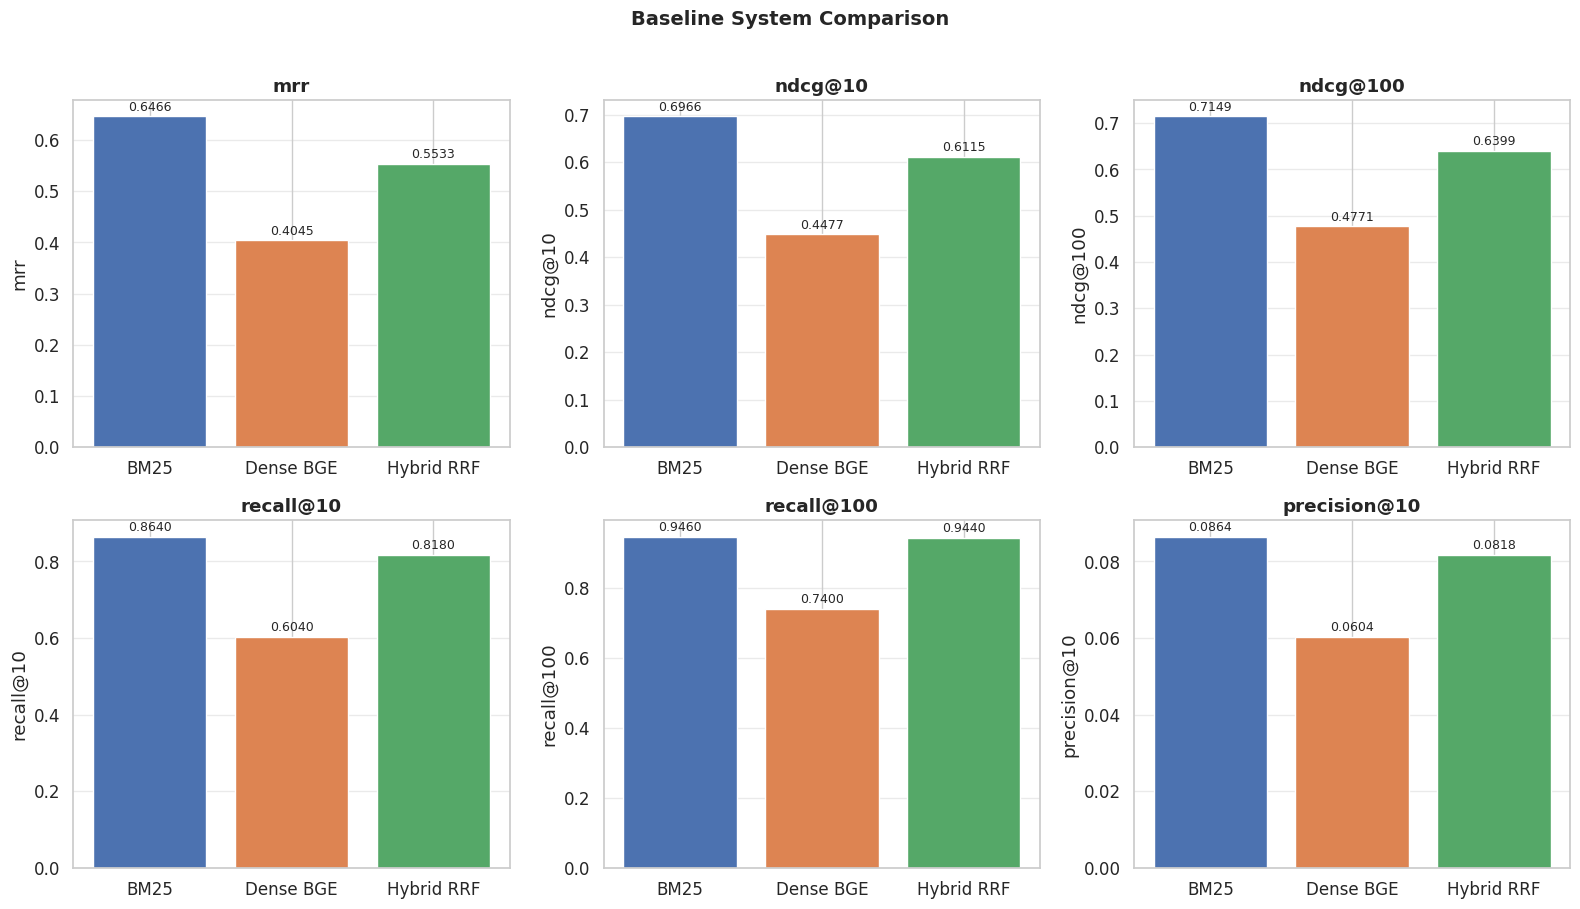

In [ ]:
# ── Baseline visualization ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, KEY_METRICS):
    vals = [rows[i].get(metric, 0) for i in range(3)]
    bars = ax.bar(['BM25', 'Dense BGE', 'Hybrid RRF'], vals, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Baseline System Comparison', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 13 — BM25 Hyperparameter Tuning

Now that we use real BM25-Okapi, changing k1/b should produce different results (unlike the previous TF-IDF implementation where all configs gave identical NDCG@10=0.6323).

In [ ]:
bm25_configs = [
    (0.9, 0.4), (1.2, 0.5), (1.2, 0.75), (1.5, 0.5), (1.5, 0.75),
    (1.8, 0.6), (1.8, 0.8), (2.0, 0.75), (2.0, 0.9),
]

bm25_results = []
for k1, b in bm25_configs:
    print(f"  k1={k1}, b={b} ...", end=' ')
    sr = SparseRetriever(k1=k1, b=b)
    sr.build_index(doc_ids, tokenized_corpus)
    agg, _ = sr.evaluate(queries_raw, qrels, processor, evaluator, top_k=TOP_K)
    row = {'k1': k1, 'b': b, **{m: round(agg[m],4) for m in ['mrr','ndcg@10','ndcg@100','recall@10','recall@100']}}
    bm25_results.append(row)
    print(f"NDCG@10={row['ndcg@10']:.4f}")

bm25_df = pd.DataFrame(bm25_results)
print("\n=== BM25 Hyperparameter Search ===")
print(bm25_df.to_string(index=False))

best = bm25_df.loc[bm25_df['ndcg@10'].idxmax()]
BEST_BM25_K1, BEST_BM25_B = float(best['k1']), float(best['b'])
print(f"\n>>> Best BM25: k1={BEST_BM25_K1}, b={BEST_BM25_B} (NDCG@10={best['ndcg@10']:.4f})")

# Verify configs produce DIFFERENT results (sanity check for real BM25)
unique_scores = bm25_df['ndcg@10'].nunique()
print(f"\nSanity check: {unique_scores} distinct NDCG@10 values across {len(bm25_configs)} configs")
assert unique_scores > 1, "BUG: All BM25 configs produce identical results — k1/b are not being used!"

# Rebuild with best config
sparse_retriever = SparseRetriever(k1=BEST_BM25_K1, b=BEST_BM25_B)
sparse_retriever.build_index(doc_ids, tokenized_corpus)
print(f"BM25 rebuilt with k1={BEST_BM25_K1}, b={BEST_BM25_B}")

  k1=0.9, b=0.4 ... 

BM25 search:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7157
  k1=1.2, b=0.5 ... 

BM25 search:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7054
  k1=1.2, b=0.75 ... 

...

NDCG@10=0.6909
  k1=2.0, b=0.75 ... 

BM25 search:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.6918
  k1=2.0, b=0.9 ... 

BM25 search:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.6864

=== BM25 Hyperparameter Search ===
 k1    b    mrr  ndcg@10  ndcg@100  recall@10  recall@100
0.9 0.40 0.6716   0.7157    0.7347      0.864       0.952
1.2 0.50 0.6594   0.7054    0.7253      0.860       0.952
1.2 0.75 0.6514   0.7026    0.7190      0.872       0.946
1.5 0.50 0.6593   0.7031    0.7238      0.852       0.946
1.5 0.75 0.6466   0.6966    0.7149      0.864       0.946
1.8 0.60 0.6506   0.6965    0.7173      0.852       0.948
1.8 0.80 0.6408   0.6909    0.7099      0.858       0.946
2.0 0.75 0.6429   0.6918    0.7110      0.856       0.946
2.0 0.90 0.6350   0.6864    0.7042      0.858       0.942

>>> Best BM25: k1=0.9, b=0.4 (NDCG@10=0.7157)

Sanity check: 9 distinct NDCG@10 values across 9 configs
BM25 rebuilt with k1=0.9, b=0.4


---
## Section 14 — RRF k Hyperparameter Search

In [ ]:
rrf_k_values = [3, 5, 10, 20, 40, 60, 80, 100]
rrf_results = []

for k_val in rrf_k_values:
    print(f"  RRF k={k_val} ...", end=' ')
    rrf_tmp = ReciprocalRankFusion(k=k_val)
    hr = HybridRetriever(sparse=sparse_retriever, dense=dense_retriever, rrf=rrf_tmp,
                          processor=processor, fetch_k=FETCH_K)
    agg, _ = hr.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)
    row = {'rrf_k': k_val, **{m: round(agg[m],4) for m in ['mrr','ndcg@10','ndcg@100','recall@10','recall@100']}}
    rrf_results.append(row)
    print(f"NDCG@10={row['ndcg@10']:.4f}")

rrf_df = pd.DataFrame(rrf_results)
print("\n=== RRF k Search ===")
print(rrf_df.to_string(index=False))

best_rrf = rrf_df.loc[rrf_df['ndcg@10'].idxmax()]
BEST_RRF_K = int(best_rrf['rrf_k'])
print(f"\n>>> Best RRF k={BEST_RRF_K} (NDCG@10={best_rrf['ndcg@10']:.4f})")

  RRF k=3 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.6737
  RRF k=5 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.6742
  RRF k=10 ... 

...

NDCG@10=0.6112
  RRF k=80 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.6030
  RRF k=100 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.5954

=== RRF k Search ===
 rrf_k    mrr  ndcg@10  ndcg@100  recall@10  recall@100
     3 0.6205   0.6737    0.6944      0.852       0.946
     5 0.6212   0.6742    0.6949      0.852       0.946
    10 0.6070   0.6631    0.6838      0.852       0.946
    20 0.5924   0.6487    0.6722      0.842       0.946
    40 0.5702   0.6275    0.6543      0.828       0.946
    60 0.5559   0.6112    0.6427      0.808       0.946
    80 0.5483   0.6030    0.6360      0.800       0.946
   100 0.5434   0.5954    0.6317      0.786       0.946

>>> Best RRF k=5 (NDCG@10=0.6742)


---
## Section 15 — Weighted RRF Experiment

In [ ]:
weight_configs = [
    (0.3, 0.7), (0.4, 0.6), (0.5, 0.5), (0.55, 0.45),
    (0.6, 0.4), (0.65, 0.35), (0.7, 0.3), (0.75, 0.25),
    (0.8, 0.2), (0.9, 0.1),
]

weight_results = []
for bw, dw in weight_configs:
    print(f"  BM25_w={bw}, Dense_w={dw} ...", end=' ')
    rrf_tmp = ReciprocalRankFusion(k=BEST_RRF_K, weights=[bw, dw])
    hr = HybridRetriever(sparse=sparse_retriever, dense=dense_retriever, rrf=rrf_tmp,
                          processor=processor, fetch_k=FETCH_K, bm25_weight=bw, dense_weight=dw)
    agg, _ = hr.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)
    row = {'bm25_w': bw, 'dense_w': dw,
           **{m: round(agg[m],4) for m in ['mrr','ndcg@10','ndcg@100','recall@10','recall@100','precision@10']}}
    weight_results.append(row)
    print(f"NDCG@10={row['ndcg@10']:.4f}")

weight_df = pd.DataFrame(weight_results)
print("\n=== Weighted RRF Results ===")
print(weight_df.to_string(index=False))

best_w = weight_df.loc[weight_df['ndcg@10'].idxmax()]
BEST_BM25_W, BEST_DENSE_W = float(best_w['bm25_w']), float(best_w['dense_w'])
print(f"\n>>> Best weights: BM25={BEST_BM25_W}, Dense={BEST_DENSE_W} (NDCG@10={best_w['ndcg@10']:.4f})")

  BM25_w=0.3, Dense_w=0.7 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.5303
  BM25_w=0.4, Dense_w=0.6 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.5835
  BM25_w=0.5, Dense_w=0.5 ... 

...

NDCG@10=0.7169
  BM25_w=0.8, Dense_w=0.2 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7183
  BM25_w=0.9, Dense_w=0.1 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7154

=== Weighted RRF Results ===
 bm25_w  dense_w    mrr  ndcg@10  ndcg@100  recall@10  recall@100  precision@10
   0.30     0.70 0.4646   0.5303    0.5668      0.776       0.932        0.0776
   0.40     0.60 0.5092   0.5835    0.6070      0.836       0.942        0.0836
   0.50     0.50 0.6212   0.6742    0.6949      0.852       0.946        0.0852
   0.55     0.45 0.6407   0.6896    0.7103      0.854       0.948        0.0854
   0.60     0.40 0.6547   0.7012    0.7217      0.858       0.952        0.0858
   0.65     0.35 0.6606   0.7062    0.7261      0.860       0.950        0.0860
   0.70     0.30 0.6673   0.7117    0.7312      0.862       0.950        0.0862
   0.75     0.25 0.6736   0.7169    0.7363      0.864       0.952        0.0864
   0.80     0.20 0.6761   0.7183    0.7383      0.862       0.952        0.0862
   0.90     0.10 0.6721   0.7154    0.7358      0.862       0.956        0.0862

>>> Best weights: BM25=0.8, Dense=0.2 (NDCG@10=0.7183)


---
## Section 16 — Candidate Pool Size Experiment

In [ ]:
pool_sizes = [50, 100, 200, 300, 500]
pool_results = []

for pool in pool_sizes:
    print(f"  Pool={pool} ...", end=' ')
    rrf_tmp = ReciprocalRankFusion(k=BEST_RRF_K, weights=[BEST_BM25_W, BEST_DENSE_W])
    hr = HybridRetriever(sparse=sparse_retriever, dense=dense_retriever, rrf=rrf_tmp,
                          processor=processor, fetch_k=pool, bm25_weight=BEST_BM25_W, dense_weight=BEST_DENSE_W)
    t0 = time.perf_counter()
    agg, _ = hr.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)
    latency = (time.perf_counter()-t0)/len(queries_raw)*1000
    row = {'pool': pool, 'latency_ms': round(latency,2),
           **{m: round(agg[m],4) for m in ['mrr','ndcg@10','ndcg@100','recall@10','recall@100']}}
    pool_results.append(row)
    print(f"NDCG@10={row['ndcg@10']:.4f}  Recall@100={row['recall@100']:.4f}")

pool_df = pd.DataFrame(pool_results)
print("\n=== Pool Size Results ===")
print(pool_df.to_string(index=False))

best_pool = pool_df.loc[pool_df['ndcg@10'].idxmax()]
BEST_POOL = int(best_pool['pool'])
print(f"\n>>> Best pool: {BEST_POOL} (NDCG@10={best_pool['ndcg@10']:.4f})")

  Pool=50 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7184  Recall@100=0.9440
  Pool=100 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7184  Recall@100=0.9520
  Pool=200 ... 

...

NDCG@10=0.7183  Recall@100=0.9520
  Pool=300 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7186  Recall@100=0.9540
  Pool=500 ... 

Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

NDCG@10=0.7207  Recall@100=0.9560

=== Pool Size Results ===
 pool  latency_ms    mrr  ndcg@10  ndcg@100  recall@10  recall@100
   50      412.82 0.6761   0.7184    0.7370      0.862       0.944
  100      401.82 0.6762   0.7184    0.7383      0.862       0.952
  200      400.11 0.6761   0.7183    0.7383      0.862       0.952
  300      401.80 0.6766   0.7186    0.7388      0.862       0.954
  500      405.61 0.6787   0.7207    0.7407      0.864       0.956

>>> Best pool: 500 (NDCG@10=0.7207)


---
## Section 17 — Jina Reranker v3 (Off-the-Shelf)

Evaluate the `jinaai/jina-reranker-v3` LBNL reranker before LoRA fine-tuning.

In [ ]:
jina_reranker_offshelf = JinaReranker(
    model_name=JINA_RERANKER_MODEL,
    device=DEVICE,
    max_length=JINA_MAX_LENGTH,
    batch_size=JINA_BATCH_DOCS,
)
jina_reranker_offshelf.build_index(doc_ids=doc_ids, corpus_raw=corpus_raw,
                                   chunk_texts=chunk_texts, chunk_to_doc=chunk_to_doc)

s_high = jina_reranker_offshelf._score_single(
    "What contracts did Enron sign with California utilities?",
    "Enron Corporation entered into long-term energy contracts with Pacific Gas and Electric."
)
s_low = jina_reranker_offshelf._score_single(
    "What contracts did Enron sign with California utilities?",
    "The weather forecast for tomorrow shows sunny skies and mild temperatures."
)
print(f"Reranker sanity: relevant={s_high:.4f}, irrelevant={s_low:.4f}")
assert s_high > s_low, f"Reranker sanity check failed: {s_high:.4f} vs {s_low:.4f}"

rrf_opt = ReciprocalRankFusion(k=BEST_RRF_K, weights=[BEST_BM25_W, BEST_DENSE_W])
hybrid_jina_offshelf = HybridRetriever(
    sparse=sparse_retriever, dense=dense_retriever, rrf=rrf_opt,
    processor=processor, reranker=jina_reranker_offshelf,
    fetch_k=BEST_POOL, bm25_weight=BEST_BM25_W, dense_weight=BEST_DENSE_W,
)

print("\nEvaluating Hybrid + Jina Reranker v3 (off-the-shelf)...")
offshelf_agg, offshelf_per_q = hybrid_jina_offshelf.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)
print("\n=== Hybrid + Jina Reranker v3 (off-the-shelf) ===")
for m, v in sorted(offshelf_agg.items()):
    print(f"  {m:<20}: {v:.4f}")

---
## Standalone Setup for Sections 18–20 (Fine-Tuning)

Run Sections 1–17 before the LoRA fine-tuning sections. Those sections provide the TREC Legal data, preprocessed corpus, BM25S index, dense FAISS index, evaluator, and retriever classes needed below.

In [ ]:
required_for_lora = ["corpus_raw", "queries_raw", "qrels", "train_pairs_raw", "sparse_retriever", "processor"]
missing = [name for name in required_for_lora if name not in globals()]
if missing:
    raise RuntimeError(f"Run Sections 1–17 before LoRA fine-tuning. Missing: {missing}")
print("LoRA prerequisites are available.")

---
## Section 18 — LoRA Fine-Tuning of jina-reranker-v3 on TREC Legal 2010

This replaces full-parameter `CrossEncoder.fit()` with PEFT LoRA (`r=16`, `alpha=32`) over the Jina/Qwen attention and FFN projections. The manual loop keeps the pretrained LBNL interaction behavior intact while adapting relevance scoring to legal e-discovery judgments.

In [ ]:
def tokenize_pair(query, document, tokenizer, max_length=512):
    """Tokenize a pointwise relevance prompt for jina-reranker-v3 LoRA training."""
    prompt = (
        f"<|im_start|>system\nYou are a search relevance expert.\n<|im_end|>\n"
        f"<|im_start|>user\nQuery: {query}\nDocument: {document}\n<|im_end|>"
    )
    return tokenizer(prompt, max_length=max_length, truncation=True, padding="max_length", return_tensors="pt")

class TRECLegalRerankDataset(torch.utils.data.Dataset):
    """HuggingFace-native dataset of (query, legal document, label) triples for LoRA."""
    def __init__(self, examples, tokenizer, max_length=512):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        query, doc, label = self.examples[idx]
        enc = tokenize_pair(query, doc, self.tokenizer, self.max_length)
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float),
        }

def evaluate_lora_mrr(model, tokenizer, val_samples, device, max_length=FT_MAX_LENGTH, at_k=10):
    """Small validation MRR@10 evaluator used during manual LoRA training."""
    model.eval()
    rr = []
    with torch.no_grad():
        for sample in val_samples:
            docs = sample.get("positive", []) + sample.get("negative", [])
            labels = [1] * len(sample.get("positive", [])) + [0] * len(sample.get("negative", []))
            if not docs or not any(labels):
                continue
            scores = []
            for doc in docs[:at_k * 4]:
                enc = tokenize_pair(sample["query"], doc, tokenizer, max_length)
                enc = {k: v.to(device) for k, v in enc.items()}
                scores.append(float(model(**enc).logits.squeeze().detach().cpu()))
            ranked = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
            rank = next((i + 1 for i, idx in enumerate(ranked[:at_k]) if labels[idx] == 1), None)
            rr.append(1.0 / rank if rank else 0.0)
    model.train()
    return float(np.mean(rr)) if rr else 0.0

def fine_tune_jina_lora(base_model_name, train_dataset, val_samples, lora_config, output_path, device,
                        num_epochs=FT_NUM_EPOCHS, batch_size=FT_BATCH_SIZE, lr=FT_LEARNING_RATE,
                        grad_accum_steps=FT_GRAD_ACCUM, warmup_ratio=FT_WARMUP_RATIO):
    """Full manual LoRA fine-tuning loop for jina-reranker-v3 on TREC Legal 2010.

    Uses BCEWithLogitsLoss over pointwise query/document prompts while LoRA adapts
    attention and FFN projections. The saved artifact is the adapter directory.
    """
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    base_model = AutoModelForSequenceClassification.from_pretrained(
        base_model_name,
        num_labels=1,
        torch_dtype=torch.float16 if "cuda" in device else torch.float32,
        trust_remote_code=True,
    )
    peft_model = get_peft_model(base_model, lora_config)
    peft_model.print_trainable_parameters()
    peft_model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    optimizer = AdamW([p for p in peft_model.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
    total_steps = max(1, len(train_loader) * num_epochs // grad_accum_steps)
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    loss_fn = torch.nn.BCEWithLogitsLoss()

    history = {"step": [], "loss": [], "val_mrr@10": []}
    best_mrr = -1.0
    global_step = 0
    os.makedirs(output_path, exist_ok=True)

    try:
        for epoch in range(num_epochs):
            peft_model.train()
            running_loss = 0.0
            optimizer.zero_grad(set_to_none=True)
            for step, batch in enumerate(tqdm(train_loader, desc=f"LoRA epoch {epoch+1}/{num_epochs}"), start=1):
                batch = {k: v.to(device) for k, v in batch.items()}
                labels = batch.pop("labels")
                outputs = peft_model(**batch)
                logits = outputs.logits.squeeze(-1).float()
                loss = loss_fn(logits, labels) / grad_accum_steps
                loss.backward()
                running_loss += float(loss.detach().cpu()) * grad_accum_steps

                if step % grad_accum_steps == 0 or step == len(train_loader):
                    torch.nn.utils.clip_grad_norm_(peft_model.parameters(), max_norm=1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad(set_to_none=True)
                    global_step += 1

                    if global_step % 20 == 0:
                        avg_loss = running_loss / max(step, 1)
                        print(f"step={global_step} loss={avg_loss:.4f}")
                    if global_step % 200 == 0 or global_step == total_steps:
                        val_mrr = evaluate_lora_mrr(peft_model, tokenizer, val_samples, device)
                        avg_loss = running_loss / max(step, 1)
                        history["step"].append(global_step)
                        history["loss"].append(avg_loss)
                        history["val_mrr@10"].append(val_mrr)
                        print(f"validation MRR@10={val_mrr:.4f}")
                        if val_mrr > best_mrr:
                            best_mrr = val_mrr
                            peft_model.save_pretrained(output_path)
                            tokenizer.save_pretrained(output_path)
        peft_model.save_pretrained(output_path)
        tokenizer.save_pretrained(output_path)
    except KeyboardInterrupt:
        print("Interrupted. Saving current LoRA adapter checkpoint before raising.")
        peft_model.save_pretrained(output_path)
        tokenizer.save_pretrained(output_path)
        raise

    with open(os.path.join(output_path, "training_metadata.pkl"), "wb") as f:
        pickle.dump({"history": history, "lora_r": LORA_R, "lora_alpha": LORA_ALPHA, "examples": len(train_dataset)}, f)
    return output_path, history

print("Building LoRA training data from TREC Legal 2010 training topics...")
train_examples_lora = []
n_positives = n_explicit_hard_neg = n_bm25_neg = 0
for pair in tqdm(train_pairs_raw, desc="Building training triples"):
    q_text = pair["query"]
    pos_ids = [d for d in pair["pos_doc_ids"] if d in corpus_raw]
    neg_ids = [d for d in pair["hard_neg_doc_ids"] if d in corpus_raw]
    for pos_id in pos_ids:
        rel = qrels_all.get(pair["query_id"], {}).get(pos_id, 1)
        label = POSITIVE_LABEL_HIGH_REL if rel >= 2 else POSITIVE_LABEL_PARTIAL_REL
        doc_text = processor.combine_fields_dense(corpus_raw.get(pos_id, {}))[:3000]
        train_examples_lora.append((q_text, doc_text, label))
        n_positives += 1
    max_explicit_neg = min(len(pos_ids) * MAX_NEG_PER_POS, len(neg_ids))
    for neg_id in random.sample(neg_ids, max_explicit_neg) if max_explicit_neg else []:
        doc_text = processor.combine_fields_dense(corpus_raw.get(neg_id, {}))[:3000]
        train_examples_lora.append((q_text, doc_text, 0.0))
        n_explicit_hard_neg += 1
    if AUGMENT_NEGATIVES:
        assessed = set(pos_ids) | set(neg_ids)
        bm25_cands = sparse_retriever.search(processor.tokenize(q_text), top_k=20)
        neg_from_bm25 = 0
        for neg_id, _ in bm25_cands:
            if neg_id in assessed:
                continue
            doc_text = processor.combine_fields_dense(corpus_raw.get(neg_id, {}))[:3000]
            train_examples_lora.append((q_text, doc_text, UNASSESSED_NEGATIVE_LABEL))
            n_bm25_neg += 1
            neg_from_bm25 += 1
            if neg_from_bm25 >= 2:
                break

print(f"Training triples: {len(train_examples_lora):,}")
print(f"  Positives              : {n_positives:,}")
print(f"  Explicit hard negatives: {n_explicit_hard_neg:,}")
print(f"  BM25 mined negatives   : {n_bm25_neg:,}")
assert len(train_examples_lora) > 0, "No LoRA training examples were created. Check training qrels/corpus IDs."

tokenizer_for_ft = AutoTokenizer.from_pretrained(JINA_RERANKER_MODEL, trust_remote_code=True)
if tokenizer_for_ft.pad_token is None:
    tokenizer_for_ft.pad_token = tokenizer_for_ft.eos_token

val_samples_lora = []
for qid in list(queries_raw.keys())[:min(10, len(queries_raw))]:
    qtext = queries_raw[qid]
    gold_ids = {did for did, rel in qrels[qid].items() if rel >= QREL_MIN_REL}
    candidates = sparse_retriever.search(processor.tokenize(qtext), top_k=30)
    pos_docs, neg_docs = [], []
    for did, _ in candidates:
        doc_text = processor.combine_fields_dense(corpus_raw.get(did, {}))[:2000]
        if did in gold_ids:
            pos_docs.append(doc_text)
        else:
            neg_docs.append(doc_text)
    if not pos_docs:
        for gid in list(gold_ids)[:3]:
            pos_docs.append(processor.combine_fields_dense(corpus_raw.get(gid, {}))[:2000])
    val_samples_lora.append({"query": qtext, "positive": pos_docs, "negative": neg_docs})

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
)

RUN_LORA_TRAINING = False
if RUN_LORA_TRAINING:
    lora_adapter_path, lora_history = fine_tune_jina_lora(
        base_model_name=JINA_RERANKER_MODEL,
        train_dataset=TRECLegalRerankDataset(train_examples_lora, tokenizer_for_ft, FT_MAX_LENGTH),
        val_samples=val_samples_lora,
        lora_config=lora_config,
        output_path=FT_OUTPUT_PATH,
        device=DEVICE,
        num_epochs=FT_NUM_EPOCHS,
        batch_size=FT_BATCH_SIZE,
        lr=FT_LEARNING_RATE,
        grad_accum_steps=FT_GRAD_ACCUM,
    )
    print(f"\nLoRA adapters saved to {lora_adapter_path}")
    if lora_history.get("step"):
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.plot(lora_history["step"], lora_history["loss"], label="loss")
        ax1.set_ylabel("Loss")
        ax2 = ax1.twinx()
        ax2.plot(lora_history["step"], lora_history["val_mrr@10"], color="orange", label="MRR@10")
        ax2.set_ylabel("Validation MRR@10")
        plt.title("LoRA Training Curve")
        plt.savefig("lora_training_curve.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("Set RUN_LORA_TRAINING=True to launch fine-tuning.")

---
## Section 19 — Evaluate Fine-Tuned jina-reranker-v3

In [ ]:
def load_finetuned_jina_reranker(base_model_name, lora_adapter_path, device):
    """Load a PEFT LoRA adapter, merge it into jina-reranker-v3, and return model/tokenizer."""
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    base_model = AutoModelForSequenceClassification.from_pretrained(
        base_model_name,
        num_labels=1,
        torch_dtype=torch.float16 if "cuda" in device else torch.float32,
        trust_remote_code=True,
    )
    peft_model = PeftModel.from_pretrained(base_model, lora_adapter_path)
    merged_model = peft_model.merge_and_unload()
    merged_model.to(device)
    merged_model.eval()
    return merged_model, tokenizer

if os.path.isdir(FT_OUTPUT_PATH) and len(os.listdir(FT_OUTPUT_PATH)) > 0:
    ft_jina_model, ft_tokenizer = load_finetuned_jina_reranker(JINA_RERANKER_MODEL, FT_OUTPUT_PATH, DEVICE)
    ft_jina_reranker = JinaReranker(device=DEVICE)
    ft_jina_reranker._model = ft_jina_model
    ft_jina_reranker._tokenizer = ft_tokenizer
    ft_jina_reranker.build_index(doc_ids=doc_ids, corpus_raw=corpus_raw,
                                  chunk_texts=chunk_texts, chunk_to_doc=chunk_to_doc)

    s_high = ft_jina_reranker._score_single(
        "What contracts did Enron sign with California utilities?",
        "Enron Corporation entered into long-term energy contracts with Pacific Gas and Electric."
    )
    s_low = ft_jina_reranker._score_single(
        "What contracts did Enron sign with California utilities?",
        "The weather forecast for tomorrow shows sunny skies and mild temperatures."
    )
    print(f"Fine-tuned reranker sanity: relevant={s_high:.4f}, irrelevant={s_low:.4f}")
    assert s_high > s_low, "Fine-tuned Jina sanity check failed."

    rrf_final = ReciprocalRankFusion(k=BEST_RRF_K, weights=[BEST_BM25_W, BEST_DENSE_W])
    hybrid_ft = HybridRetriever(
        sparse=sparse_retriever, dense=dense_retriever, rrf=rrf_final,
        processor=processor, reranker=ft_jina_reranker,
        fetch_k=BEST_POOL, bm25_weight=BEST_BM25_W, dense_weight=BEST_DENSE_W,
    )
    print("\nEvaluating Hybrid + Fine-Tuned Jina Reranker v3 (LoRA)...")
    ft_agg, ft_per_q = hybrid_ft.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)
else:
    print(f"No LoRA adapter found at {FT_OUTPUT_PATH}. Using off-the-shelf scores as placeholder for summary.")
    ft_agg, ft_per_q = offshelf_agg, offshelf_per_q
    hybrid_ft = hybrid_jina_offshelf

rrf_norank = ReciprocalRankFusion(k=BEST_RRF_K, weights=[BEST_BM25_W, BEST_DENSE_W])
hybrid_norank = HybridRetriever(
    sparse=sparse_retriever, dense=dense_retriever, rrf=rrf_norank,
    processor=processor, reranker=None,
    fetch_k=BEST_POOL, bm25_weight=BEST_BM25_W, dense_weight=BEST_DENSE_W,
)
print("Evaluating Hybrid (no reranker, optimized params)...")
norank_agg, norank_per_q = hybrid_norank.evaluate(queries_raw, qrels, evaluator, top_k=TOP_K)

---
## Section 20 — Final Comparison

In [ ]:
bm25_opt_agg, _ = sparse_retriever.evaluate(queries_raw, qrels, processor, evaluator, top_k=TOP_K)
SUMMARY_METRICS = ['mrr', 'ndcg@10', 'ndcg@100', 'recall@10', 'recall@100', 'precision@10']
summary_rows = [
    {'System': 'BM25 (optimized)',                                **{m: round(bm25_opt_agg.get(m,0),4) for m in SUMMARY_METRICS}},
    {'System': 'Dense BGE',                                       **{m: round(dense_agg.get(m,0),4) for m in SUMMARY_METRICS}},
    {'System': 'Hybrid RRF (no rerank)',                          **{m: round(norank_agg.get(m,0),4) for m in SUMMARY_METRICS}},
    {'System': 'Hybrid + Jina Reranker v3 (off-shelf)',           **{m: round(offshelf_agg.get(m,0),4) for m in SUMMARY_METRICS}},
    {'System': 'Hybrid + Jina Reranker v3 (LoRA fine-tuned)',     **{m: round(ft_agg.get(m,0),4) for m in SUMMARY_METRICS}},
]
summary_df = pd.DataFrame(summary_rows).set_index('System')
print("\n" + "="*100)
print("FINAL SUMMARY — TREC Legal 2010 Hybrid IR System")
print("="*100)
print(summary_df.to_string())
best_system = summary_df['ndcg@10'].idxmax()
best_ndcg = summary_df['ndcg@10'].max()
print(f"\n>>> Best system: {best_system} (NDCG@10 = {best_ndcg:.4f})")
if best_ndcg >= 0.65:
    print("TARGET ACHIEVED: NDCG@10 >= 0.65")
else:
    print(f"Target not yet met: {best_ndcg:.4f} < 0.65 (gap: {0.65-best_ndcg:.4f})")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_final = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
system_labels = ['BM25\n(optimized)', 'Dense\nBGE', 'Hybrid\n(no rerank)',
                 'Jina\n(off-shelf)', 'Jina+LoRA\n(fine-tuned)']
for ax, metric in zip(axes, SUMMARY_METRICS):
    vals = [summary_rows[i].get(metric, 0) for i in range(5)]
    bars = ax.bar(range(5), vals, color=colors_final, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
    ax.set_xticks(range(5))
    ax.set_xticklabels(system_labels, fontsize=7)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.4)
    if metric == 'ndcg@10':
        ax.axhline(y=0.65, color='red', linestyle='--', alpha=0.7, label='Target: 0.65')
        ax.legend(fontsize=8)
plt.suptitle('Final System Comparison — TREC Legal 2010 IR', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('final_comparison_trec_legal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 21 — Error Analysis

In [ ]:
best_hybrid = hybrid_ft if ft_agg.get('ndcg@10',0) > norank_agg.get('ndcg@10',0) else hybrid_norank
bm25_res, dense_res, hybrid_res = {}, {}, {}
for qid, qtext in tqdm(queries_raw.items(), desc='Collecting results'):
    qtoks = processor.tokenize(qtext)
    bm25_res[qid] = sparse_retriever.search(qtoks, top_k=10)
    dense_res[qid] = dense_retriever.search(qtext, top_k=10)
    hybrid_res[qid] = best_hybrid.retrieve(qtext, top_k=10)

def hits_at_k(results, relevant_set, k=10):
    return int(bool({d for d,_ in results[:k]} & relevant_set))

failures = []
for qid in queries_raw:
    rel = {did for did, grade in qrels.get(qid, {}).items() if grade >= QREL_MIN_REL}
    if not rel:
        continue
    failures.append({
        'qid': qid,
        'bm25': hits_at_k(bm25_res.get(qid,[]), rel),
        'dense': hits_at_k(dense_res.get(qid,[]), rel),
        'hybrid': hits_at_k(hybrid_res.get(qid,[]), rel),
    })
only_bm25_fail = [f for f in failures if f['bm25']==0 and f['dense']==1]
only_dense_fail = [f for f in failures if f['dense']==0 and f['bm25']==1]
hybrid_unique = [f for f in failures if f['hybrid']==1 and f['bm25']==0 and f['dense']==0]
all_fail = [f for f in failures if f['bm25']==0 and f['dense']==0 and f['hybrid']==0]
print(f"Total queries         : {len(failures)}")
print(f"BM25 fails, Dense hits: {len(only_bm25_fail)}")
print(f"Dense fails, BM25 hits: {len(only_dense_fail)}")
print(f"Hybrid unique wins    : {len(hybrid_unique)}")
print(f"All systems fail      : {len(all_fail)}")
print("\n=== Example Failures (All Systems Miss) ===")
for f in all_fail[:5]:
    qid = f['qid']
    print(f"\n  Query: {queries_raw[qid][:150]}")
    rel = list(qrels[qid].keys())
    print(f"  First relevant doc: {rel[0] if rel else 'none'}")
    if rel:
        print(f"  Relevant title: {corpus_raw.get(rel[0], {}).get('title','')[:100]}")

---
## Section 22 — Latency Analysis

In [ ]:
print("Measuring latencies...")
bm25_lat = sparse_retriever.measure_latency(queries_raw, processor)
dense_lat = dense_retriever.measure_latency(queries_raw)

def measure_hybrid_latency(hybrid, queries, n_queries=20):
    sample = list(queries.values())[:n_queries]
    latencies = []
    for qtext in sample:
        t0 = time.perf_counter()
        hybrid.retrieve(qtext, top_k=TOP_K)
        latencies.append((time.perf_counter()-t0)*1000)
    return {'mean_ms': round(np.mean(latencies),2), 'median_ms': round(np.median(latencies),2), 'p95_ms': round(np.percentile(latencies,95),2)}

latency_df = pd.DataFrame([
    {'System': 'BM25 (optimized)', **bm25_lat},
    {'System': 'Dense BGE', **dense_lat},
    {'System': 'JinaReranker (off-shelf, hybrid incl. retrieval)', **measure_hybrid_latency(hybrid_jina_offshelf, queries_raw)},
    {'System': 'JinaReranker (LoRA, hybrid incl. retrieval)', **measure_hybrid_latency(hybrid_ft, queries_raw)},
])
print("\n=== Latency Analysis (ms per query) ===")
print(latency_df.to_string(index=False))

In [ ]:
print("\n" + "="*70)
print("OPTIMIZATION CONFIGURATION SUMMARY")
print("="*70)
print(f"  Dense Model      : {SBERT_MODEL}")
print(f"  Query Prefix     : BGE instruction prefix enabled")
print(f"  BM25 k1          : {BEST_BM25_K1}")
print(f"  BM25 b           : {BEST_BM25_B}")
print(f"  RRF k            : {BEST_RRF_K}")
print(f"  BM25 weight      : {BEST_BM25_W}")
print(f"  Dense weight     : {BEST_DENSE_W}")
print(f"  Candidate pool   : {BEST_POOL}")
print(f"  Reranker         : {JINA_RERANKER_MODEL} (LoRA target: {LORA_TARGET})")
print(f"  FAISS index      : HNSW efSearch=128, METRIC_INNER_PRODUCT")
print(f"  Preprocessing    : Legal email, analysis-gated cleaning, thread-aware chunking")
print(f"  Eval mode        : {EVAL_MODE}")
print("="*70)

---
## Section 23 — Discussion

### Dataset Switch Rationale

EnronQA is closer to a closed QA task because each query maps to one relevant email. TREC Legal 2010 is a more realistic legal e-discovery benchmark: topics have multiple relevant documents, graded relevance, long email threads, and shallow pooled judgments. That makes graded NDCG meaningful and exposes recall/reranking tradeoffs that EnronQA hides.

### jina-reranker-v3 vs CrossEncoder

The original notebook used a pointwise `sentence-transformers` cross-encoder. This notebook uses `jinaai/jina-reranker-v3`, a listwise reranker based on Last But Not Late (LBNL) interaction. Instead of scoring one query-document pair independently, the model can score candidate documents in a shared context so documents can attend to one another before relevance embeddings are extracted. This gives comparative ranking signals unavailable to pointwise cross-encoders.

### LoRA vs Full Fine-Tuning

LoRA is preferred for a 0.6B-parameter reranker because it adapts a small number of low-rank matrices while preserving the pretrained LBNL behavior. The configuration here follows the paper-style setting (`r=16`, `alpha=32`) and targets attention plus FFN projections. Adapter checkpoints are small and fast to iterate on compared with full model checkpoints.

### Legal Domain Challenges

Legal e-discovery adds long documents, repeated disclaimers, forwarded email chains, domain acronyms, Bates-like identifiers, overlapping requests for production, and incomplete qrel pools. The preprocessing and evaluation choices in this notebook are designed to make those assumptions measurable before they become defaults.

### References

1. Wang et al. (2025). jina-reranker-v3 / Last But Not Late interaction. arXiv:2509.25085v4.
2. Xiao, S., et al. (2023). C-Pack / BGE embedding models. arXiv:2309.07597.
3. Cormack, G.V., Clarke, C.L.A., & Buettcher, S. (2009). Reciprocal Rank Fusion outperforms Condorcet and individual Rank Learning Methods. SIGIR 2009.
4. Robertson, S., & Zaragoza, H. (2009). The Probabilistic Relevance Framework: BM25 and Beyond. Foundations and Trends in IR.